# Tiki E-Commerce Data Analysis and Visualization
## Dataset: Vietnamese Tiki E-Commerce - Fashion & Accessories

**Data source:** https://www.kaggle.com/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset

## Main Research Themes
1. **Pay Later / BNPL:** Determine whether `pay_later` is mainly a tool for higher-priced products or a broad demand stimulus; measure `quantity_sold` uplift and effects by price segment.
2. **Rating paradox:** Compare 5.0-star products with 4.7-4.9-star products while controlling for `review_count`, to test whether social proof matters more than a perfect score.
3. **Gender behavior - Men's vs Women's Shoes and Bags:** Compare price sensitivity, discount levels, reviews, delivery type, and sales velocity across both gender-labeled categories (`Shoes`, `Bags`). This helps avoid biased conclusions from a single product category.

## Notebook Structure
- Part 1: Setup & Load
- Part 2: Data Cleaning & Feature Engineering
- Part 3: EDA by research theme
- Part 4: Probability Distribution
- Part 5: Hypothesis Testing
- Part 6: Correlation Analysis
- Part 7: Multiple Linear Regression


## Part 1: Setup and Data Loading


### 1.1 Import Libraries


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter, ScalarFormatter
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kstest, shapiro, norm, lognorm
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries were imported successfully.')

All libraries were imported successfully.


### 1.2 Configure Data Path


In [2]:
# DATA PATH CONFIGURATIOn
try:
    from google.colab import drive
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

USE_COLAB = IN_COLAB

if USE_COLAB:
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/data_V/'
else:
    DATA_PATH = './dataset/'

FILE_CONFIGS = [
    ('vietnamese_tiki_products_men_bags.csv',            'Bags', 'Male'),
    ('vietnamese_tiki_products_women_bags.csv',          'Bags', 'Female'),
    ('vietnamese_tiki_products_men_shoes.csv',           'Shoes', 'Male'),
    ('vietnamese_tiki_products_women_shoes.csv',         'Shoes', 'Female'),
    ('vietnamese_tiki_products_backpacks_suitcases.csv', 'Backpacks - Suitcases', 'Unisex'),
    ('vietnamese_tiki_products_fashion_accessories.csv', 'Accessories', 'Unisex'),
]

print(f'Data path: {DATA_PATH}')


Mounted at /content/drive
Data path: /content/drive/MyDrive/data_V/


### 1.3 Load Each CSV File and Inspect Structure


In [3]:
all_columns = {}
all_dtypes = {}

for file_name, category, gender in FILE_CONFIGS:
    full_path = os.path.join(DATA_PATH, file_name)

    if not os.path.exists(full_path):
        print(f'[WARNING] File not found: {file_name}')
        continue

    df_temp = pd.read_csv(full_path)
    all_columns[file_name] = set(df_temp.columns)
    all_dtypes[file_name] = df_temp.dtypes.astype(str).to_dict()

    missing = df_temp.isnull().sum()
    missing = missing[missing > 0]

    print(f'=== {file_name} ===')
    print(f'Rows: {df_temp.shape[0]:,}')
    print(f'Columns : {df_temp.shape[1]}')
    print('Sample rows:')
    display(df_temp.head(2))

    if len(missing):
        print('Missing values:')
        print(missing.to_dict())
    else:
        print('No missing values')
    print()


=== vietnamese_tiki_products_men_bags.csv ===
Rows: 4,234
Columns : 19
Sample rows:


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,179731388,Túi Đeo Chéo Nam Nhỏ Gọn Tiện Lợi Phong Cách H...,Túi Đeo Chéo Nam Nhỏ Gọn Tiện Lợi Phong Cách...,15000,15000,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,488,10,0,False,Túi đeo chéo nam,0
1,1,207737218,Túi đeo chéo mini phối màu xíu xinh phong cách...,Chào mừng bạn đến với cửa hàng của tôiSản phẩm...,9000,9000,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,286,7,0,False,Túi đeo chéo nam,0


No missing values

=== vietnamese_tiki_products_women_bags.csv ===
Rows: 4,325
Columns : 19
Sample rows:


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,259480018,Túi Xách Nữ Da Mềm Thời Trang Du Lịch Phong Cá...,Mô Tả Sản Phẩm:Túi Xách Nữ Da Mềm Thời ...,85000,85000,dropship,OEM,0,0.0,0,False,Túi Xinh Store 2022,115,7,0,False,Root,0
1,1,260801038,Túi Xách Đeo Vai Kẹp Nách Đi Học Đi Chơi Thời...,Mô Tả Sản Phẩm:Túi Xách Đeo Vai Kẹp Nác...,89000,89000,dropship,OEM,0,0.0,0,False,Bảo Khánh Store,112,9,2382,False,Root,0


No missing values

=== vietnamese_tiki_products_men_shoes.csv ===
Rows: 5,745
Columns : 19
Sample rows:


...

No missing values

=== vietnamese_tiki_products_backpacks_suitcases.csv ===
Rows: 5,361
Columns : 19
Sample rows:


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,179731375,Balo nữ da dầy thời trang unisex màu sắc tươi ...,Balo nữ da dầy thời trang unisex màu sắc tươ...,14250,14250,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,488,10,0,False,Balo nữ,0
1,1,249221065,Ví da đựng thẻ ngân hàng (7 màu) - 9205,...,10260,10260,dropship,OEM,0,0.0,0,False,SHOP THỜI TRANG 2N,166,2,0,False,Root,0


No missing values

=== vietnamese_tiki_products_fashion_accessories.csv ===
Rows: 16,019
Columns : 19
Sample rows:


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,171126920,tang đeo cài áo,"Ghim kẹp cài áo màu trắng, màu đen dù...",10000,10000,dropship,OEM,2,5.0,0,False,Siêu thị vàng mã Thiên Hương Phước,539,3,0,False,Root,106
1,1,154165256,Bộ Móc May Áo Ngực Loại 2 Móc Cài,Khách Sỉ: Vui lòng Inbox Shop❀ComLiti Shop xin...,7000,7000,dropship,OEM,1,4.0,0,False,Comliti Shop,602,6,0,True,Cài Áo,5


Missing values:
{'brand': 2}



### 1.4 Compare Schema Across the Six Files


In [4]:
ref_file = FILE_CONFIGS[0][0]
ref_cols = all_columns.get(ref_file, set())
ref_types = all_dtypes.get(ref_file, {})

print('=== SCHEMA CONSISTENCY CHECK ===')

for fname in all_columns:
    if fname == ref_file:
        continue

    diff_cols = ref_cols.symmetric_difference(all_columns[fname])
    diff_types = {
        c: (ref_types.get(c), all_dtypes[fname].get(c))
        for c in ref_types
        if all_dtypes[fname].get(c) != ref_types.get(c)
    }

    status = 'OK' if not diff_cols and not diff_types else 'DIFFERENCE FOUND'
    print(f'{status}: {fname}')
    if diff_cols:
        print(f'Different columns: {diff_cols}')
    if diff_types:
        print(f'Different dtypes: {diff_types}')


=== SCHEMA CONSISTENCY CHECK ===
OK: vietnamese_tiki_products_women_bags.csv
OK: vietnamese_tiki_products_men_shoes.csv
OK: vietnamese_tiki_products_women_shoes.csv
OK: vietnamese_tiki_products_backpacks_suitcases.csv
OK: vietnamese_tiki_products_fashion_accessories.csv


### 1.5 Merge the Six Files into One Dataset


In [5]:
all_dfs = []

for file_name, category, gender in FILE_CONFIGS:
    full_path = os.path.join(DATA_PATH, file_name)
    if not os.path.exists(full_path):
        continue

    df_temp = pd.read_csv(full_path)
    df_temp['main_category'] = category
    df_temp['target_gender'] = gender
    all_dfs.append(df_temp)

if not all_dfs:
    raise FileNotFoundError('No CSV files were found. Please check DATA_PATH and the dataset folder.')

df_tiki = pd.concat(all_dfs, ignore_index=True)

if 'Unnamed: 0' in df_tiki.columns:
    df_tiki.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Total records: {df_tiki.shape[0]:,}')
print(f'Total columns: {df_tiki.shape[1]}')
display(df_tiki.head())


Total records: 41,603
Total columns: 20


,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold,main_category,target_gender
0,179731388,Túi Đeo Chéo Nam Nhỏ Gọn Tiện Lợi Phong Cách H...,Túi Đeo Chéo Nam Nhỏ Gọn Tiện Lợi Phong Cách...,15000,15000,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,488,10,0,False,Túi đeo chéo nam,0,Bags,Male
1,207737218,Túi đeo chéo mini phối màu xíu xinh phong cách...,Chào mừng bạn đến với cửa hàng của tôiSản phẩm...,9000,9000,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,286,7,0,False,Túi đeo chéo nam,0,Bags,Male
2,179731359,Túi đeo chéo mini nam nữ thời trang nhỏ gọn bỏ...,"Chất liệu : PVC cao cấp chống thấm nước, bảo...",15000,15000,dropship,OEM,0,0.0,0,False,Thiên Ân Balo,488,10,0,False,Túi đeo chéo nam,0,Bags,Male
3,102862656,Túi Đeo Chéo Hà Mã thời trang hai ngăn siêu r...,‭ ⇒ Màu sắc : Đen ⇒ Kích thước: gọn g...,8500,8500,dropship,OEM,0,0.0,0,False,Xưởng may balo Đà Nẵng,831,10,0,False,Root,0,Bags,Male
4,198227440,Tất Nam Nữ Trơn Cổ Ngắn Vớ Nam Thời Trang Cao ...,- Tất - Vớ là một loại vật dụng không thể thiế...,1350,1350,dropship,OEM,0,0.0,0,False,THỜI TRANG QUANG STORE,355,10,0,False,Túi đeo chéo nam,0,Bags,Male


## Part 2: Data Cleaning


### 2.1 Check Missing Values


In [6]:
missing_count = df_tiki.isnull().sum()
missing_pct = missing_count / len(df_tiki) * 100
missing_report = pd.DataFrame({
    'Missing count': missing_count,
    'Missing rate (%)': missing_pct.round(2)
})
missing_report = missing_report[missing_report['Missing count'] > 0]
print(missing_report)


                  Missing count  Missing rate (%)
fulfillment_type              1               0.0
brand                         2               0.0


### 2.2 Handle Missing Values


In [7]:
print(df_tiki['fulfillment_type'].value_counts(dropna=False))

df_tiki['fulfillment_type'] = df_tiki['fulfillment_type'].fillna('dropship')
df_tiki['brand'] = df_tiki['brand'].fillna('OEM')
df_tiki['quantity_sold'] = df_tiki['quantity_sold'].fillna(0)

print('Total remaining missing values:')
print(df_tiki.isnull().sum().sum())


fulfillment_type
dropship            40689
tiki_delivery         709
seller_delivery       203
instant_delivery        1
NaN                     1
Name: count, dtype: int64
Total remaining missing values:
0


### 2.3 Remove Duplicate Products by `id`


In [8]:
n_before = len(df_tiki)
dup_count = df_tiki.duplicated(subset='id').sum()
print(f'Duplicate product IDs: {dup_count:,}')

if dup_count > 0:
    df_tiki.drop_duplicates(subset='id', keep='first', inplace=True)

print(f'Rows sau khi loc: {len(df_tiki):,}')
print(f'Rows da xoa: {n_before - len(df_tiki):,}')


Duplicate product IDs: 27
Rows sau khi loc: 41,576
Rows da xoa: 27


### 2.4 Remove Products with Zero Price


In [9]:
zero_price = df_tiki[df_tiki['price'] == 0]
print(f'Products with price = 0: {len(zero_price)}')

if len(zero_price) > 0:
    display(zero_price[['name', 'price', 'quantity_sold']].head())

# Zero-price products are usually gifts or promotions and are not suitable for price and revenue analysis.
df_tiki = df_tiki[df_tiki['price'] > 0].copy()
print(f'Rows con lai: {len(df_tiki):,}')


Products with price = 0: 1


,name,price,quantity_sold
7413,[Gift] Túi Canvas Morra,0,3


Rows con lai: 41,575


### 2.5 Detect Outliers with the IQR Method


=== price ===
Q1=39,000
Q3=210,000
IQR=171,000
Outliers: 4,912 (11.81%)
=== quantity_sold ===
Q1=0
Q3=5
IQR=5
Outliers: 6,442 (15.49%)


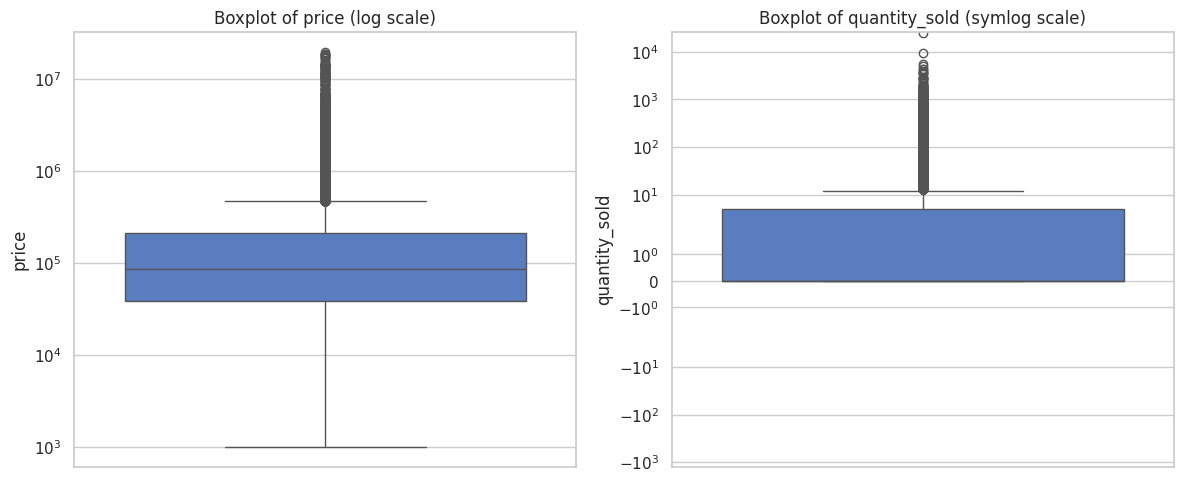

In [10]:
def iqr_outlier_report(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    pct = n_out / len(series) * 100

    print(f'=== {col_name} ===')
    print(f'Q1={Q1:,.0f}')
    print(f'Q3={Q3:,.0f}')
    print(f'IQR={IQR:,.0f}')
    print(f'Outliers: {n_out:,} ({pct:.2f}%)')
    return lower, upper

p_lo, p_hi = iqr_outlier_report(df_tiki['price'], 'price')
q_lo, q_hi = iqr_outlier_report(df_tiki['quantity_sold'], 'quantity_sold')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_tiki['price'], ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Boxplot of price (log scale)')
sns.boxplot(y=df_tiki['quantity_sold'], ax=axes[1])
axes[1].set_yscale('symlog')
axes[1].set_title('Boxplot of quantity_sold (symlog scale)')
plt.tight_layout(); plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The boxplots show that both `price` and `quantity_sold` are strongly right-skewed. The log/symlog scales are necessary because a small number of high-price or high-sales products would otherwise dominate the visual scale. These outliers are kept because they represent real e-commerce behavior rather than simple data-entry errors.


**Outlier interpretation and handling**

`price` and `quantity_sold` have high outlier rates, which is expected in e-commerce data. A small number of products can be very expensive or sell far above the average. The notebook keeps these outliers because they may contain important business signals, but later sections use log transformations to reduce the influence of long-tailed variables.


### 2.6 Feature Engineering for the Three Research Themes


In [11]:
'''
SALES VELOCITY
The data is collected from when the item was first upload up to the day collected, so we use sales_velocity because it gives the average number of units sold per day.
'''

df_tiki['sales_velocity'] = df_tiki['quantity_sold'] / (df_tiki['date_created'] + 1)

'''
DISCOUNT PERCENTAGE
'''

df_tiki['discount_percent'] = np.where(
    df_tiki['original_price'] > 0,
    ((df_tiki['original_price'] - df_tiki['price']) / df_tiki['original_price']) * 100,
    0.0
)
df_tiki['discount_percent'] = df_tiki['discount_percent'].clip(lower=0)


df_tiki['is_OEM'] = (df_tiki['brand'] == 'OEM').astype(int)
df_tiki['has_video_int'] = df_tiki['has_video'].astype(int)
df_tiki['pay_later_int'] = df_tiki['pay_later'].astype(int)
df_tiki['is_tiki_delivery'] = (df_tiki['fulfillment_type'] == 'tiki_delivery').astype(int)
df_tiki['revenue_proxy'] = df_tiki['price'] * df_tiki['quantity_sold']

price_bins = [0, 100000, 300000, 500000, 1000000, np.inf]
price_labels = ['<=100k', '100k-300k', '300k-500k', '500k-1m', '>1m']
df_tiki['price_segment'] = pd.cut(df_tiki['price'], bins=price_bins, labels=price_labels, include_lowest=True)

review_bins = [-1, 0, 3, 10, 50, 100, np.inf]
review_labels = ['0 review', '1-3 reviews', '4-10 reviews', '11-50 reviews', '51-100 reviews', '100+ reviews']
df_tiki['review_tier'] = pd.cut(df_tiki['review_count'], bins=review_bins, labels=review_labels)

def classify_rating(r):
    if r == 5.0:
        return '5.0 star'
    if 4.7 <= r < 5.0:
        return '4.7-4.9 star'
    if 4.0 <= r < 4.7:
        return '4.0-4.6 star'
    if r > 0:
        return '<4.0 star'
    return 'No rating'

df_tiki['rating_tier'] = df_tiki['rating_average'].apply(classify_rating)

print(df_tiki.shape)
display(df_tiki.head())


(41575, 30)


,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,...,sales_velocity,discount_percent,is_OEM,has_video_int,pay_later_int,is_tiki_delivery,revenue_proxy,price_segment,review_tier,rating_tier
0,179731388,Túi Đeo Chéo Nam Nhỏ Gọn Tiện Lợi Phong Cách H...,Túi Đeo Chéo Nam Nhỏ Gọn Tiện Lợi Phong Cách...,15000,15000,dropship,OEM,0,0.0,0,...,0.0,0.0,1,0,0,0,0,<=100k,0 review,No rating
1,207737218,Túi đeo chéo mini phối màu xíu xinh phong cách...,Chào mừng bạn đến với cửa hàng của tôiSản phẩm...,9000,9000,dropship,OEM,0,0.0,0,...,0.0,0.0,1,0,0,0,0,<=100k,0 review,No rating
2,179731359,Túi đeo chéo mini nam nữ thời trang nhỏ gọn bỏ...,"Chất liệu : PVC cao cấp chống thấm nước, bảo...",15000,15000,dropship,OEM,0,0.0,0,...,0.0,0.0,1,0,0,0,0,<=100k,0 review,No rating
3,102862656,Túi Đeo Chéo Hà Mã thời trang hai ngăn siêu r...,‭ ⇒ Màu sắc : Đen ⇒ Kích thước: gọn g...,8500,8500,dropship,OEM,0,0.0,0,...,0.0,0.0,1,0,0,0,0,<=100k,0 review,No rating
4,198227440,Tất Nam Nữ Trơn Cổ Ngắn Vớ Nam Thời Trang Cao ...,- Tất - Vớ là một loại vật dụng không thể thiế...,1350,1350,dropship,OEM,0,0.0,0,...,0.0,0.0,1,0,0,0,0,<=100k,0 review,No rating


## Part 3: Exploratory Data Analysis by Research Theme

This section is synchronized with the three source notebooks used to prepare the presentation:

- `52300143_pay_later_tiki_fashion.ipynb` for Pay Later / BNPL.
- `Rating (1).ipynb` for the rating paradox.
- `PhanTich.ipynb` for gender-category behavior in shoes and bags.

The code keeps the source-notebook logic and chart types, while adapting column names and labels to the unified English pipeline of this notebook.


### 3.1 Overall Descriptive Statistics and Category Structure


In [12]:
display(df_tiki.describe().round(2))

cat_summary = df_tiki.groupby('main_category').agg(
    SKU_count=('id', 'count'),
    median_price=('price', 'median'),
    median_quantity_sold=('quantity_sold', 'median'),
    estimated_revenue=('revenue_proxy', 'sum'),
    BNPL_rate=('pay_later', 'mean'),
    video_rate=('has_video', 'mean')
)
cat_summary[['BNPL_rate', 'video_rate']] = (cat_summary[['BNPL_rate', 'video_rate']] * 100).round(2)
display(cat_summary.sort_values('estimated_revenue', ascending=False))


,id,original_price,price,review_count,rating_average,favourite_count,date_created,number_of_images,vnd_cashback,quantity_sold,sales_velocity,discount_percent,is_OEM,has_video_int,pay_later_int,is_tiki_delivery,revenue_proxy
count,4.157500e+04,41575.00,41575.00,41575.00,41575.00,41575.0,41575.00,41575.00,41575.00,41575.00,41575.00,41575.00,41575.00,41575.0,41575.00,41575.00,4.157500e+04
mean,1.465191e+08,304986.35,272365.43,3.11,1.38,0.0,711.19,5.97,1431.46,17.78,0.04,5.81,0.74,0.1,0.44,0.02,2.078117e+06
std,6.365500e+07,851907.78,763010.64,18.23,2.11,0.0,6275.61,3.46,6389.05,168.38,0.70,13.72,0.44,0.3,0.50,0.13,2.002554e+07
min,1.599010e+05,1000.00,1000.00,0.00,0.00,0.0,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.000000e+00
25%,1.020940e+08,40000.00,39000.00,0.00,0.00,0.0,396.50,4.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.000000e+00
50%,1.523477e+08,90000.00,85000.00,0.00,0.00,0.0,616.00,6.00,0.00,0.00,0.00,0.00,1.00,0.0,0.00,0.00,0.000000e+00
75%,1.935665e+08,240000.00,210000.00,1.00,4.00,0.0,831.00,8.00,0.00,5.00,0.01,0.00,1.00,0.0,1.00,0.00,4.793000e+05
max,2.633026e+08,19800000.00,19800000.00,969.00,5.00,0.0,738076.00,70.00,167720.00,24847.00,61.00,88.57,1.00,1.0,1.00,1.00,1.656600e+09


,SKU_count,median_price,median_quantity_sold,estimated_revenue,BNPL_rate,video_rate
main_category,,,,,,
Backpacks - Suitcases,5359,159000.0,1.0,28992857627,55.74,11.55
Shoes,11661,169000.0,1.0,28309816358,65.37,9.30
Bags,8550,119000.0,0.0,15056235336,54.15,13.92
Accessories,16005,45000.0,0.0,14038799131,20.31,8.60


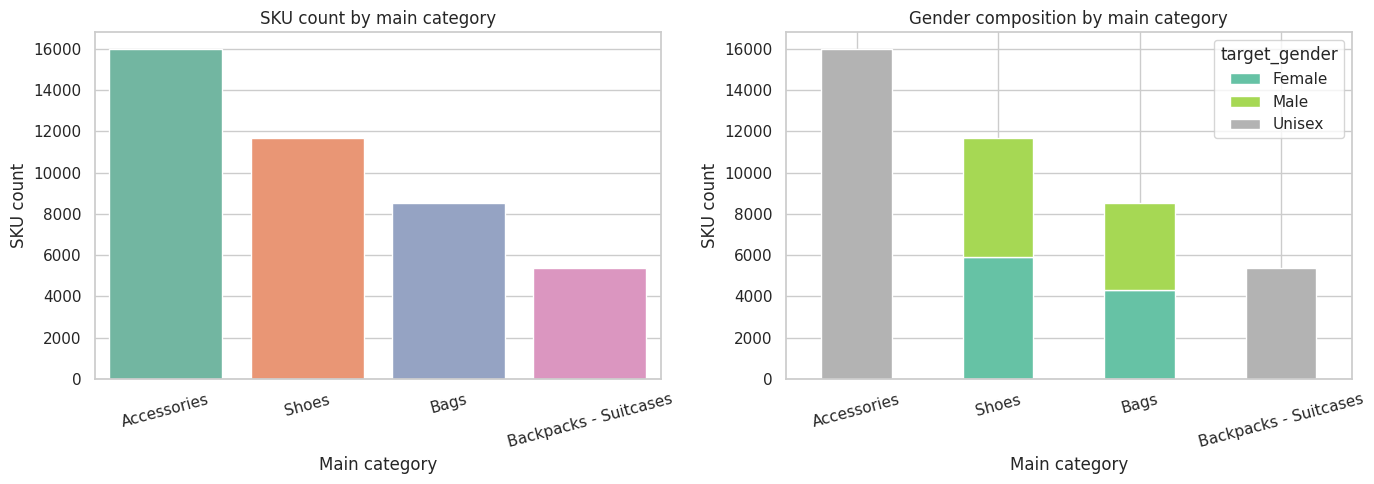

In [13]:
# Source alignment: Rating notebook category-count overview.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df_tiki['main_category'].value_counts().index
sns.countplot(data=df_tiki, x='main_category', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('SKU count by main category')
axes[0].set_xlabel('Main category')
axes[0].set_ylabel('SKU count')
axes[0].tick_params(axis='x', rotation=15)

pivot_gender = df_tiki.groupby(['main_category', 'target_gender']).size().unstack(fill_value=0)
pivot_gender.loc[order].plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('Gender composition by main category')
axes[1].set_xlabel('Main category')
axes[1].set_ylabel('SKU count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The category countplot shows the SKU structure of the merged dataset, while the stacked chart separates gender-oriented and unisex categories. This overview confirms that later comparisons should account for category composition instead of interpreting every difference as a pure behavioral effect.


### 3.2 Theme 1 - Pay Later / BNPL: Financial Lever or Mass-Market Stimulus

This subsection follows `52300143_pay_later_tiki_fashion.ipynb`: sales tiers, revenue proxy, price distribution, rating-revenue relationship, and brand positioning.


pay_later,False,True
sales_tier,,
Tier 0 (0 units),54.50,45.50
Tier 1 (1-50 units),54.85,45.15
Tier 2 (51-500 units),68.21,31.79
Tier 3 (>500 units),78.34,21.66


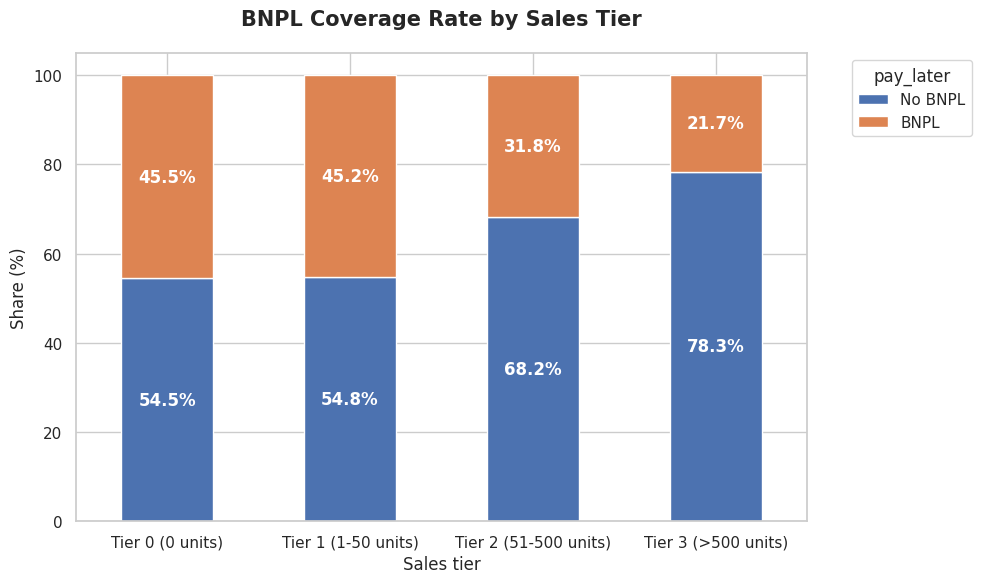

In [14]:
# Source alignment: BNPL sales-tier coverage from pay_later notebook.
bnpl_source = df_tiki.copy()
bnpl_source['sales_tier'] = pd.cut(
    bnpl_source['quantity_sold'],
    bins=[-1, 0, 50, 500, np.inf],
    labels=['Tier 0 (0 units)', 'Tier 1 (1-50 units)', 'Tier 2 (51-500 units)', 'Tier 3 (>500 units)']
)

tier_bnpl_ct = pd.crosstab(bnpl_source['sales_tier'], bnpl_source['pay_later'], normalize='index') * 100
display(tier_bnpl_ct.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
tier_bnpl_ct.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title('BNPL Coverage Rate by Sales Tier', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Sales tier')
ax.set_ylabel('Share (%)')
ax.set_xticklabels(tier_bnpl_ct.index, rotation=0)

for c in ax.containers:
    labels = [f'{w:.1f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

ax.legend(['No BNPL', 'BNPL'], title='pay_later', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** BNPL coverage is compared across cumulative sales tiers. The chart follows the Pay Later source notebook and answers whether BNPL is concentrated only among high-selling products or broadly available across different sales-performance groups.


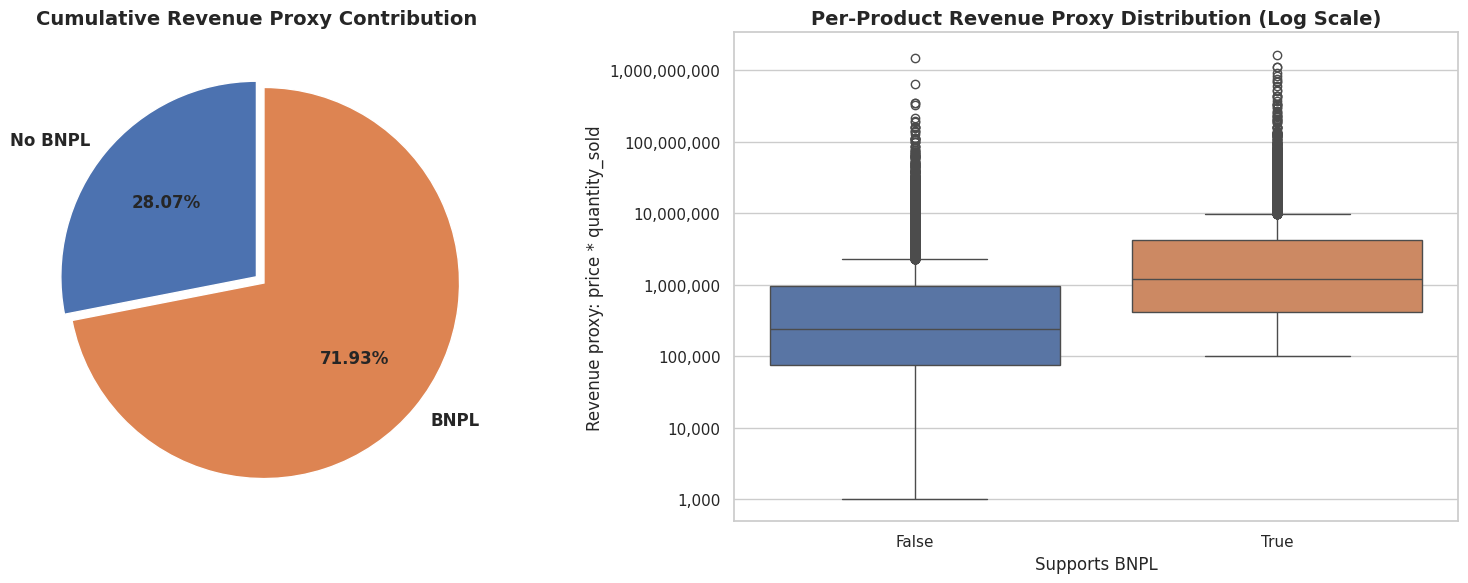

,BNPL support,Median,Q3,Q1,Min,Max
0,No,"236,000 VND","948,000 VND","76,000 VND","1,000 VND","1,490,820,000 VND"
1,Yes,"1,196,000 VND","4,158,000 VND","420,000 VND","100,000 VND","1,656,600,000 VND"


In [15]:
# Source alignment: estimated revenue contribution and per-product revenue distribution.
bnpl_source['estimated_revenue'] = bnpl_source['price'] * bnpl_source['quantity_sold']
total_revenue = bnpl_source.groupby('pay_later')['estimated_revenue'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
labels = ['No BNPL' if idx is False else 'BNPL' for idx in total_revenue.index]
explode = [0.05 if idx is True else 0 for idx in total_revenue.index]
ax1.pie(
    total_revenue,
    labels=labels,
    autopct='%1.2f%%',
    colors=['#4C72B0', '#DD8452'][:len(total_revenue)],
    startangle=90,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
ax1.set_title('Cumulative Revenue Proxy Contribution', fontsize=14, fontweight='bold')

df_revenue_positive = bnpl_source[bnpl_source['estimated_revenue'] > 0].copy()
sns.boxplot(
    data=df_revenue_positive,
    x='pay_later',
    y='estimated_revenue',
    hue='pay_later',
    palette=['#4C72B0', '#DD8452'],
    legend=False,
    ax=ax2
)
ax2.set_yscale('log')
ax2.set_title('Per-Product Revenue Proxy Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Supports BNPL')
ax2.set_ylabel('Revenue proxy: price * quantity_sold')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.tight_layout()
plt.show()

rev_stats = df_revenue_positive.groupby('pay_later')['estimated_revenue'].describe(percentiles=[0.25, 0.5, 0.75])
rev_table = rev_stats[['min', '25%', '50%', '75%', 'max']].copy()
for col in rev_table.columns:
    rev_table[col] = rev_table[col].apply(lambda x: f'{x:,.0f} VND')
rev_table = rev_table.reset_index()
rev_table['pay_later'] = rev_table['pay_later'].map({False: 'No', True: 'Yes'})
rev_table.columns = ['BNPL support', 'Min', 'Q1', 'Median', 'Q3', 'Max']
display(rev_table[['BNPL support', 'Median', 'Q3', 'Q1', 'Min', 'Max']])


<!-- chart-explanation-v2 -->
**Chart interpretation.** The pie chart summarizes the revenue-proxy share of BNPL and non-BNPL products, while the boxplot shows per-product revenue dispersion on a log scale. This view is more informative than raw median `quantity_sold` when many products have very low or zero sales.


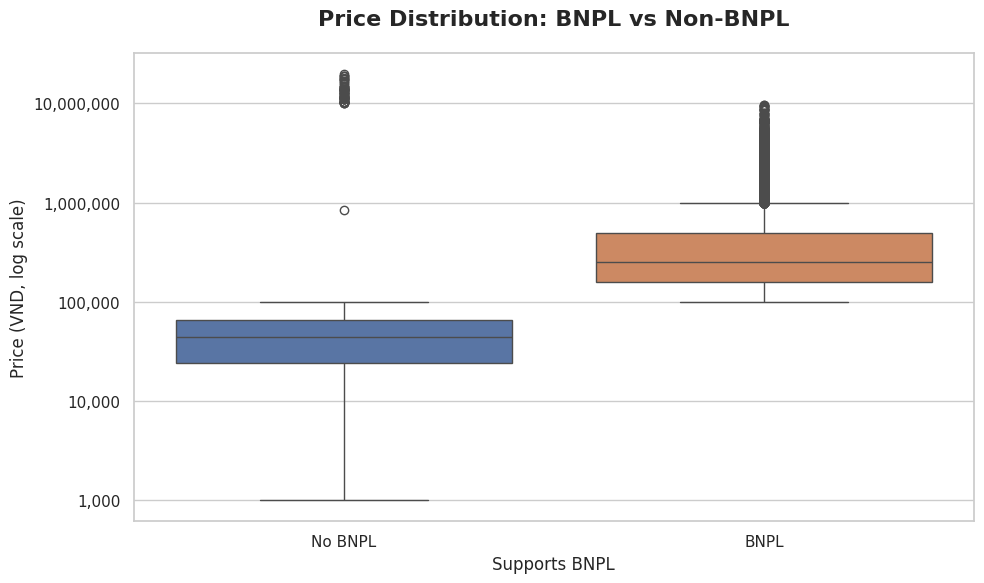

,BNPL support,Median,Q3,Q1,Min,Max
0,No,"44,000 VND","65,550 VND","24,000 VND","1,000 VND","19,800,000 VND"
1,Yes,"249,000 VND","489,000 VND","159,000 VND","100,000 VND","9,700,000 VND"


In [16]:
# Source alignment: BNPL price distribution boxplot.
fig_price, ax_price = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=bnpl_source,
    x='pay_later',
    y='price',
    hue='pay_later',
    palette=['#4C72B0', '#DD8452'],
    legend=False,
    ax=ax_price
)
ax_price.set_yscale('log')
ax_price.set_title('Price Distribution: BNPL vs Non-BNPL', fontsize=16, fontweight='bold', pad=20)
ax_price.set_xlabel('Supports BNPL')
ax_price.set_ylabel('Price (VND, log scale)')
ax_price.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax_price.set_xticklabels(['No BNPL', 'BNPL'])
plt.tight_layout()
plt.show()

price_stats = bnpl_source.groupby('pay_later')['price'].describe(percentiles=[0.25, 0.5, 0.75])
price_table = price_stats[['min', '25%', '50%', '75%', 'max']].copy()
for col in price_table.columns:
    price_table[col] = price_table[col].apply(lambda x: f'{x:,.0f} VND')
price_table = price_table.reset_index()
price_table['pay_later'] = price_table['pay_later'].map({False: 'No', True: 'Yes'})
price_table.columns = ['BNPL support', 'Min', 'Q1', 'Median', 'Q3', 'Max']
display(price_table[['BNPL support', 'Median', 'Q3', 'Q1', 'Min', 'Max']])


<!-- chart-explanation-v2 -->
**Chart interpretation.** The BNPL price boxplot shows whether Pay Later is attached mainly to higher-priced items. A higher median and upper quartile for BNPL products would support the interpretation that BNPL works as a financing lever rather than only a mass-market feature.


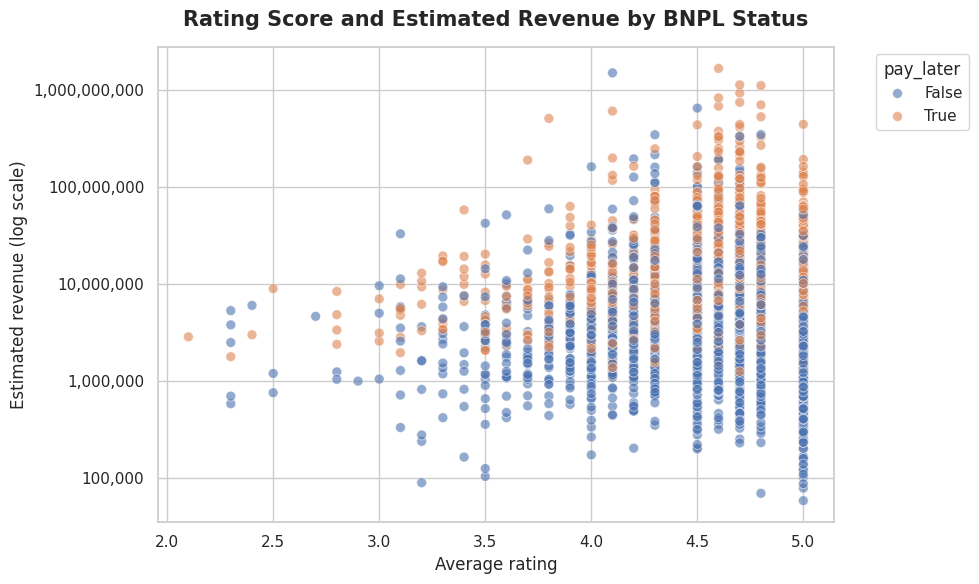

Correlation between rating_average and log estimated revenue:
Non-BNPL group: -0.023
BNPL group    : 0.136


In [17]:
# Source alignment: BNPL and rating-revenue relationship.
df_bnpl_corr = bnpl_source[(bnpl_source['estimated_revenue'] > 0) & (bnpl_source['review_count'] > 5)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_bnpl_corr,
    x='rating_average',
    y='estimated_revenue',
    hue='pay_later',
    palette=['#4C72B0', '#DD8452'],
    alpha=0.6,
    s=50,
    ax=ax
)
ax.set_yscale('log')
ax.set_title('Rating Score and Estimated Revenue by BNPL Status', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Average rating')
ax.set_ylabel('Estimated revenue (log scale)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax.legend(title='pay_later', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

corr_false = df_bnpl_corr[df_bnpl_corr['pay_later'] == False]['rating_average'].corr(np.log1p(df_bnpl_corr['estimated_revenue']))
corr_true = df_bnpl_corr[df_bnpl_corr['pay_later'] == True]['rating_average'].corr(np.log1p(df_bnpl_corr['estimated_revenue']))
print('Correlation between rating_average and log estimated revenue:')
print(f'Non-BNPL group: {corr_false:.3f}')
print(f'BNPL group    : {corr_true:.3f}')


<!-- chart-explanation-v2 -->
**Chart interpretation.** The scatter plot links average rating with estimated revenue and colors products by BNPL status. Because the y-axis is log-scaled, the chart emphasizes relative revenue differences and helps check whether rating alone explains revenue performance within BNPL and non-BNPL groups.


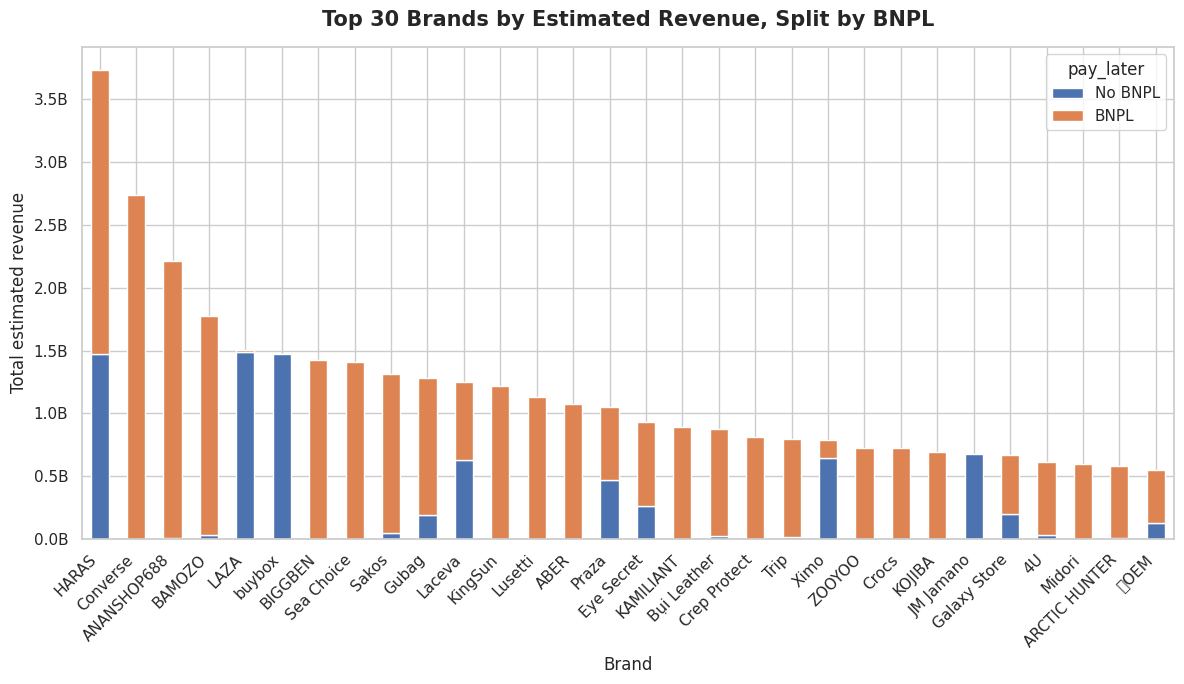

Total estimated revenue: 86,397,708,452 VND
Top 30 brand estimated revenue: 35,503,435,276 VND (41.09%)
OEM / no-brand estimated revenue: 27,093,879,835 VND (31.36%)


In [18]:
# Source alignment: top-brand revenue structure by BNPL.
df_brand = bnpl_source[(bnpl_source['brand'].notna()) & (bnpl_source['brand'] != 'OEM')].copy()
top_30_brands = df_brand.groupby('brand')['estimated_revenue'].sum().nlargest(30).index
df_top_brands = df_brand[df_brand['brand'].isin(top_30_brands)].copy()

brand_revenue = df_top_brands.groupby(['brand', 'pay_later'])['estimated_revenue'].sum().unstack(fill_value=0)
for col in [False, True]:
    if col not in brand_revenue.columns:
        brand_revenue[col] = 0
brand_revenue['total'] = brand_revenue[False] + brand_revenue[True]
brand_revenue = brand_revenue.sort_values(by='total', ascending=False).drop(columns='total')

fig, ax = plt.subplots(figsize=(12, 7))
brand_revenue.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title('Top 30 Brands by Estimated Revenue, Split by BNPL', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Brand')
ax.set_ylabel('Total estimated revenue')
ax.set_xticklabels(brand_revenue.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e9:.1f}B'))
ax.legend(['No BNPL', 'BNPL'], title='pay_later')
plt.tight_layout()
plt.show()

total_revenue_all = bnpl_source['estimated_revenue'].sum()
total_revenue_top30 = df_top_brands['estimated_revenue'].sum()
total_revenue_no_brand = bnpl_source[(bnpl_source['brand'].isna()) | (bnpl_source['brand'] == 'OEM')]['estimated_revenue'].sum()
print(f'Total estimated revenue: {total_revenue_all:,.0f} VND')
print(f'Top 30 brand estimated revenue: {total_revenue_top30:,.0f} VND ({total_revenue_top30 / total_revenue_all * 100:.2f}%)')
print(f'OEM / no-brand estimated revenue: {total_revenue_no_brand:,.0f} VND ({total_revenue_no_brand / total_revenue_all * 100:.2f}%)')


<!-- chart-explanation-v2 -->
**Chart interpretation.** The stacked brand chart shows how much estimated revenue comes from BNPL and non-BNPL products among top brands. It highlights whether BNPL adoption is concentrated in stronger brands or spread across the brand landscape.


Number of brands in the positioning matrix: 30


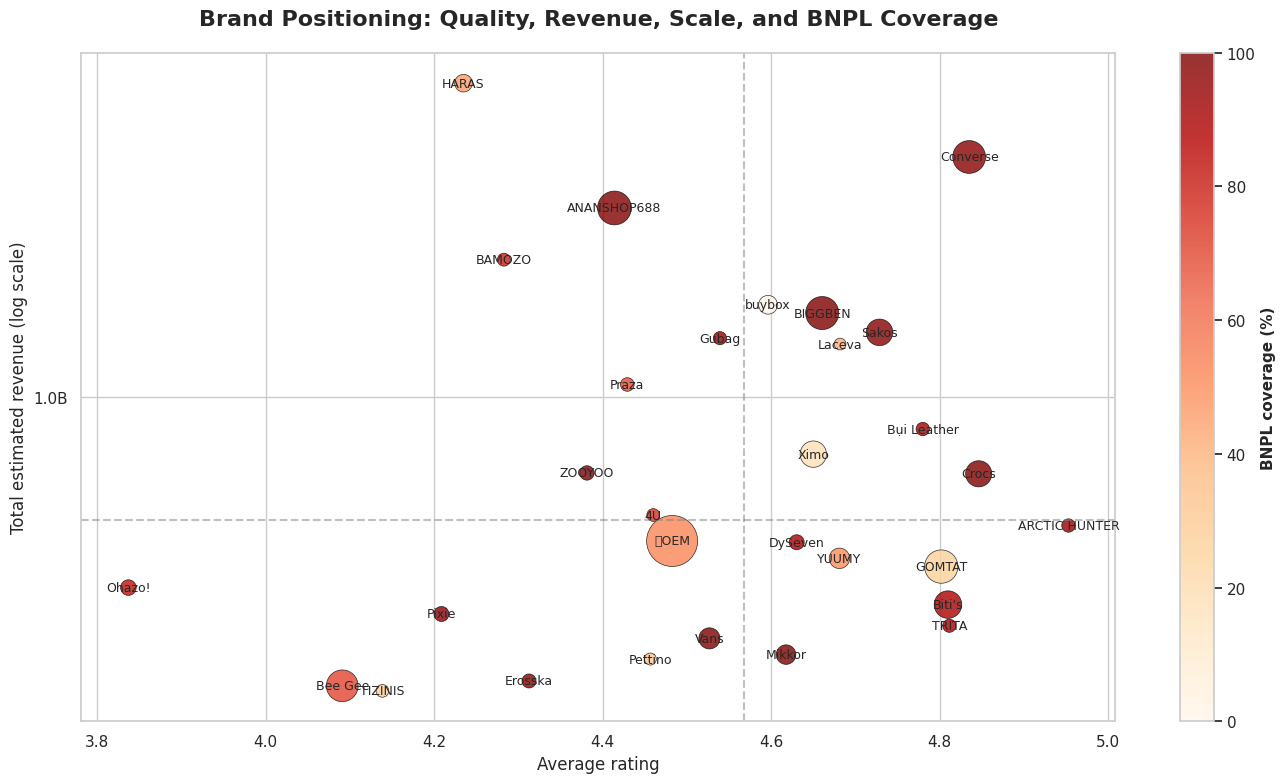

In [19]:
# Source alignment: brand positioning matrix.
df_rated_brand = df_brand[df_brand['rating_average'] > 0].copy()
brand_rating = df_rated_brand.groupby('brand')['rating_average'].mean().reset_index(name='mean_rating')
brand_metrics = df_brand.groupby('brand').agg(
    total_estimated_revenue=('estimated_revenue', 'sum'),
    total_SKU=('id', 'count'),
    BNPL_coverage=('pay_later', 'mean')
).reset_index()

brand_matrix = pd.merge(brand_metrics, brand_rating, on='brand', how='inner')
brand_matrix = brand_matrix[(brand_matrix['total_SKU'] >= 20) & (brand_matrix['total_estimated_revenue'] > 0)]
top_30_matrix = brand_matrix.nlargest(30, 'total_estimated_revenue')
print(f'Number of brands in the positioning matrix: {len(top_30_matrix)}')

if len(top_30_matrix) == 0:
    print('No qualified brand data for the positioning matrix.')
else:
    fig, ax = plt.subplots(figsize=(14, 8))
    scatter = ax.scatter(
        x=top_30_matrix['mean_rating'],
        y=top_30_matrix['total_estimated_revenue'],
        s=top_30_matrix['total_SKU'] * 3,
        c=top_30_matrix['BNPL_coverage'] * 100,
        cmap='OrRd',
        alpha=0.8,
        edgecolors='black',
        linewidth=0.5
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('BNPL coverage (%)', fontsize=11, fontweight='bold')

    for _, row in top_30_matrix.iterrows():
        ax.text(row['mean_rating'], row['total_estimated_revenue'], row['brand'], fontsize=9, ha='center', va='center')

    ax.set_yscale('log')
    ax.set_title('Brand Positioning: Quality, Revenue, Scale, and BNPL Coverage', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Average rating')
    ax.set_ylabel('Total estimated revenue (log scale)')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.1f}M'))
    ax.axvline(top_30_matrix['mean_rating'].median(), color='gray', linestyle='--', alpha=0.5)
    ax.axhline(top_30_matrix['total_estimated_revenue'].median(), color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The brand-positioning matrix combines rating, estimated revenue, SKU scale, and BNPL coverage. It is useful for identifying brands that are not only large in revenue but also have broad BNPL support and stable perceived quality.


### 3.3 Theme 2 - Rating Paradox: Perfect Rating vs Crowd Validation

This subsection follows `Rating (1).ipynb` and excludes the machine-learning part from that source notebook, because regression is handled separately in Part 7.


In [20]:
# Source alignment: rating paradox preprocessing from Rating notebook.
df_rating_source = df_tiki[(df_tiki['price'] > 0) & (df_tiki['review_count'] > 0)].copy()

bins_review_rating = [0, 3, 10, 50, np.inf]
labels_review_rating = ['1-3 reviews', '4-10 reviews', '11-50 reviews', '50+ reviews']
df_rating_source['review_tier_source'] = pd.cut(df_rating_source['review_count'], bins=bins_review_rating, labels=labels_review_rating)

def classify_rating_source(r):
    if r == 5.0:
        return '5.0 stars'
    if 4.7 <= r < 5.0:
        return '4.7-4.9 stars'
    if 4.0 <= r < 4.7:
        return '4.0-4.6 stars'
    return 'Below 4.0 stars'

df_rating_source['rating_tier_source'] = df_rating_source['rating_average'].apply(classify_rating_source)
print(f'Products used in the rating-paradox analysis: {len(df_rating_source):,} SKU')


Products used in the rating-paradox analysis: 13,014 SKU


In [21]:
# Source alignment: prove sparse-data issue and raw rating paradox.
group_5_star = df_rating_source[df_rating_source['rating_tier_source'] == '5.0 stars']
group_4_8_star = df_rating_source[df_rating_source['rating_tier_source'] == '4.7-4.9 stars']

pct_1_review_5star = (len(group_5_star[group_5_star['review_count'] == 1]) / len(group_5_star)) * 100 if len(group_5_star) else np.nan
median_sold_5star = group_5_star['quantity_sold'].median()
median_sold_48star = group_4_8_star['quantity_sold'].median()

print('=== Rating paradox surface evidence ===')
print(f"Share of 5.0-star products with exactly one review: {pct_1_review_5star:.1f}%")
print(f'Median quantity_sold - 5.0 stars      : {median_sold_5star:.0f}')
print(f'Median quantity_sold - 4.7-4.9 stars : {median_sold_48star:.0f}')
if median_sold_5star > 0:
    print(f'Raw median sales ratio, 4.7-4.9 / 5.0: {median_sold_48star / median_sold_5star:.1f}x')

rating_surface_table = pd.DataFrame({
    'rating_group': ['5.0 stars', '4.7-4.9 stars'],
    'SKU_count': [len(group_5_star), len(group_4_8_star)],
    'median_review_count': [group_5_star['review_count'].median(), group_4_8_star['review_count'].median()],
    'median_quantity_sold': [median_sold_5star, median_sold_48star]
})
display(rating_surface_table)


=== Rating paradox surface evidence ===
Share of 5.0-star products with exactly one review: 53.3%
Median quantity_sold - 5.0 stars      : 6
Median quantity_sold - 4.7-4.9 stars : 36
Raw median sales ratio, 4.7-4.9 / 5.0: 6.0x


,rating_group,SKU_count,median_review_count,median_quantity_sold
0,5.0 stars,5493,1.0,6.0
1,4.7-4.9 stars,1576,9.0,36.0


In [22]:
# Source alignment: median quantity_sold by rating tier and review tier.
pivot_analysis = pd.pivot_table(
    df_rating_source[df_rating_source['rating_tier_source'].isin(['5.0 stars', '4.7-4.9 stars'])],
    values='quantity_sold',
    index='rating_tier_source',
    columns='review_tier_source',
    aggfunc='median',
    observed=False
).fillna(0).astype(int)

print('Median cumulative quantity_sold after controlling for review tier')
display(pivot_analysis)


Median cumulative quantity_sold after controlling for review tier


review_tier_source,1-3 reviews,4-10 reviews,11-50 reviews,50+ reviews
rating_tier_source,,,,
4.7-4.9 stars,12,21,76,386
5.0 stars,4,20,67,351


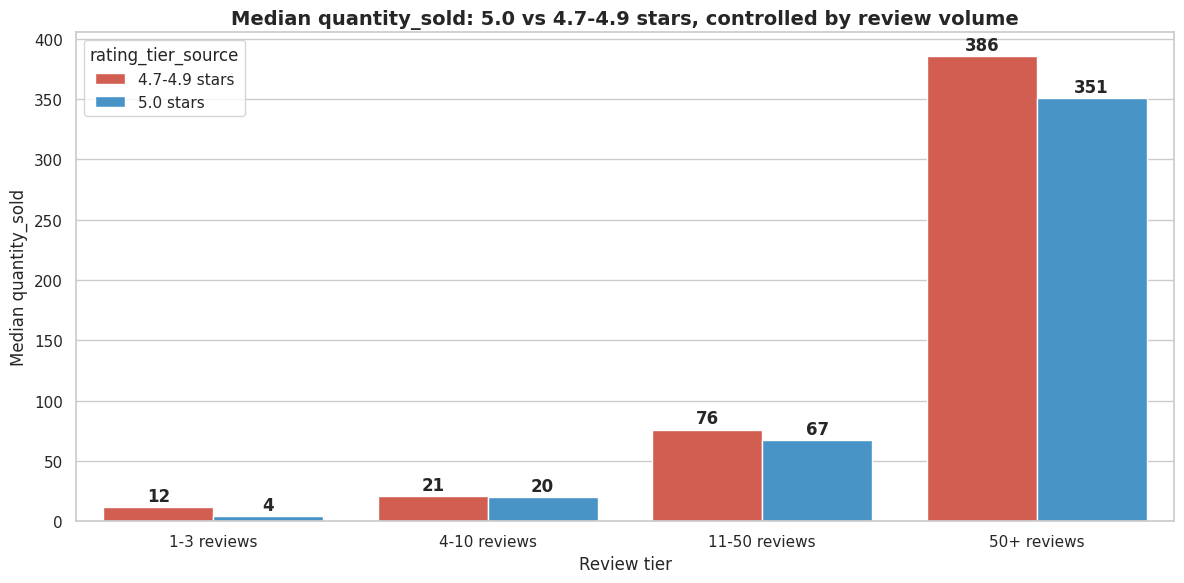

In [23]:
# Source alignment: rating-paradox barplot controlled by review tier.
plt.figure(figsize=(12, 6))
plot_data = df_rating_source[df_rating_source['rating_tier_source'].isin(['5.0 stars', '4.7-4.9 stars'])].copy()

ax = sns.barplot(
    data=plot_data,
    x='review_tier_source',
    y='quantity_sold',
    hue='rating_tier_source',
    estimator=np.median,
    errorbar=None,
    palette=['#e74c3c', '#3498db']
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontweight='bold'
        )

plt.title('Median quantity_sold: 5.0 vs 4.7-4.9 stars, controlled by review volume', fontsize=14, fontweight='bold')
plt.xlabel('Review tier')
plt.ylabel('Median quantity_sold')
plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** This barplot compares median `quantity_sold` between perfect 5.0-star products and 4.7-4.9-star products within the same review-count tier. It directly tests whether the apparent advantage of 4.7-4.9 ratings remains after controlling for social proof.


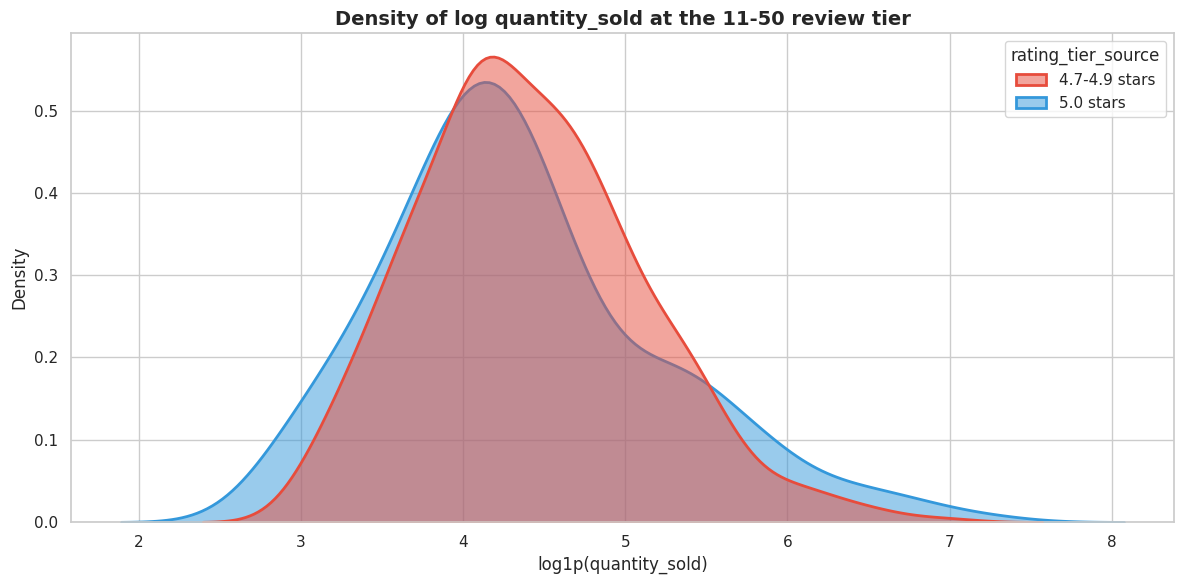

In [24]:
# Source alignment: KDE distribution at the 11-50 review tier.
plt.figure(figsize=(12, 6))

df_subset = df_rating_source[
    (df_rating_source['review_tier_source'] == '11-50 reviews') &
    (df_rating_source['rating_tier_source'].isin(['5.0 stars', '4.7-4.9 stars']))
].copy()
df_subset['log_quantity_sold'] = np.log1p(df_subset['quantity_sold'])

if len(df_subset) > 1:
    sns.kdeplot(
        data=df_subset,
        x='log_quantity_sold',
        hue='rating_tier_source',
        fill=True,
        common_norm=False,
        palette=['#e74c3c', '#3498db'],
        alpha=0.5,
        linewidth=2
    )
    plt.title('Density of log quantity_sold at the 11-50 review tier', fontsize=14, fontweight='bold')
    plt.xlabel('log1p(quantity_sold)')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough observations for KDE at the 11-50 review tier.')


<!-- chart-explanation-v2 -->
**Chart interpretation.** The KDE plot compares the distribution of log-transformed sales for the two rating groups within the 11-50 review tier. Using `log1p(quantity_sold)` reduces skewness and makes the shape of the two sales distributions easier to compare.


In [25]:
# Source alignment: Bayesian trust score and robustness illustration.
df_valid_rating = df_rating_source[(df_rating_source['rating_average'] > 0) & (df_rating_source['review_count'] > 0)].copy()
C = df_valid_rating['review_count'].mean()
m = df_valid_rating['rating_average'].mean()

def bayesian_rating(v, R, C, m):
    return (v / (v + C) * R) + (C / (v + C) * m)

df_valid_rating['bayesian_score'] = bayesian_rating(
    df_valid_rating['review_count'],
    df_valid_rating['rating_average'],
    C,
    m
)

def simulate_attack(current_rating, current_reviews, attack_stars=1, num_attacks=1):
    total_score = current_rating * current_reviews
    new_reviews = current_reviews + num_attacks
    new_score = total_score + (attack_stars * num_attacks)
    return round(new_score / new_reviews, 2)

print('=== Bayesian stability illustration ===')
print(f'Global mean rating: {m:.2f}; confidence anchor: {C:.2f} reviews')

if not df_valid_rating[(df_valid_rating['rating_average'] == 5.0) & (df_valid_rating['review_count'] == 1)].empty:
    sample_5 = df_valid_rating[(df_valid_rating['rating_average'] == 5.0) & (df_valid_rating['review_count'] == 1)].iloc[0]
    print('Sparse perfect-rating product:')
    print(f"Raw rating: {sample_5['rating_average']}; reviews: {sample_5['review_count']}; Bayesian score: {sample_5['bayesian_score']:.2f}")

if not df_valid_rating[(df_valid_rating['rating_average'].between(4.7, 4.9)) & (df_valid_rating['review_count'] > 100)].empty:
    sample_48 = df_valid_rating[(df_valid_rating['rating_average'].between(4.7, 4.9)) & (df_valid_rating['review_count'] > 100)].iloc[0]
    print('Crowd-validated high-rating product:')
    print(f"Raw rating: {sample_48['rating_average']}; reviews: {sample_48['review_count']}; Bayesian score: {sample_48['bayesian_score']:.2f}")

new_rating_A = simulate_attack(5.0, 1)
new_rating_B = simulate_attack(4.8, 100)
print(f'One 1-star review changes a 5.0-star / 1-review product to {new_rating_A}.')
print(f'One 1-star review changes a 4.8-star / 100-review product to {new_rating_B}.')


=== Bayesian stability illustration ===
Global mean rating: 4.41; confidence anchor: 9.94 reviews
Sparse perfect-rating product:
Raw rating: 5.0; reviews: 1; Bayesian score: 4.47
Crowd-validated high-rating product:
Raw rating: 4.7; reviews: 105; Bayesian score: 4.68
One 1-star review changes a 5.0-star / 1-review product to 3.0.
One 1-star review changes a 4.8-star / 100-review product to 4.76.


### 3.4 Theme 3 - Gender-Category Behavior: Shoes and Bags

This subsection follows `PhanTich.ipynb`. It keeps both shoes and bags so that the presentation does not reduce gender behavior to one product category only.


=== Shoes descriptive statistics ===
Median shoe price - Female: 158,000 VND
Median shoe price - Male: 180,000 VND


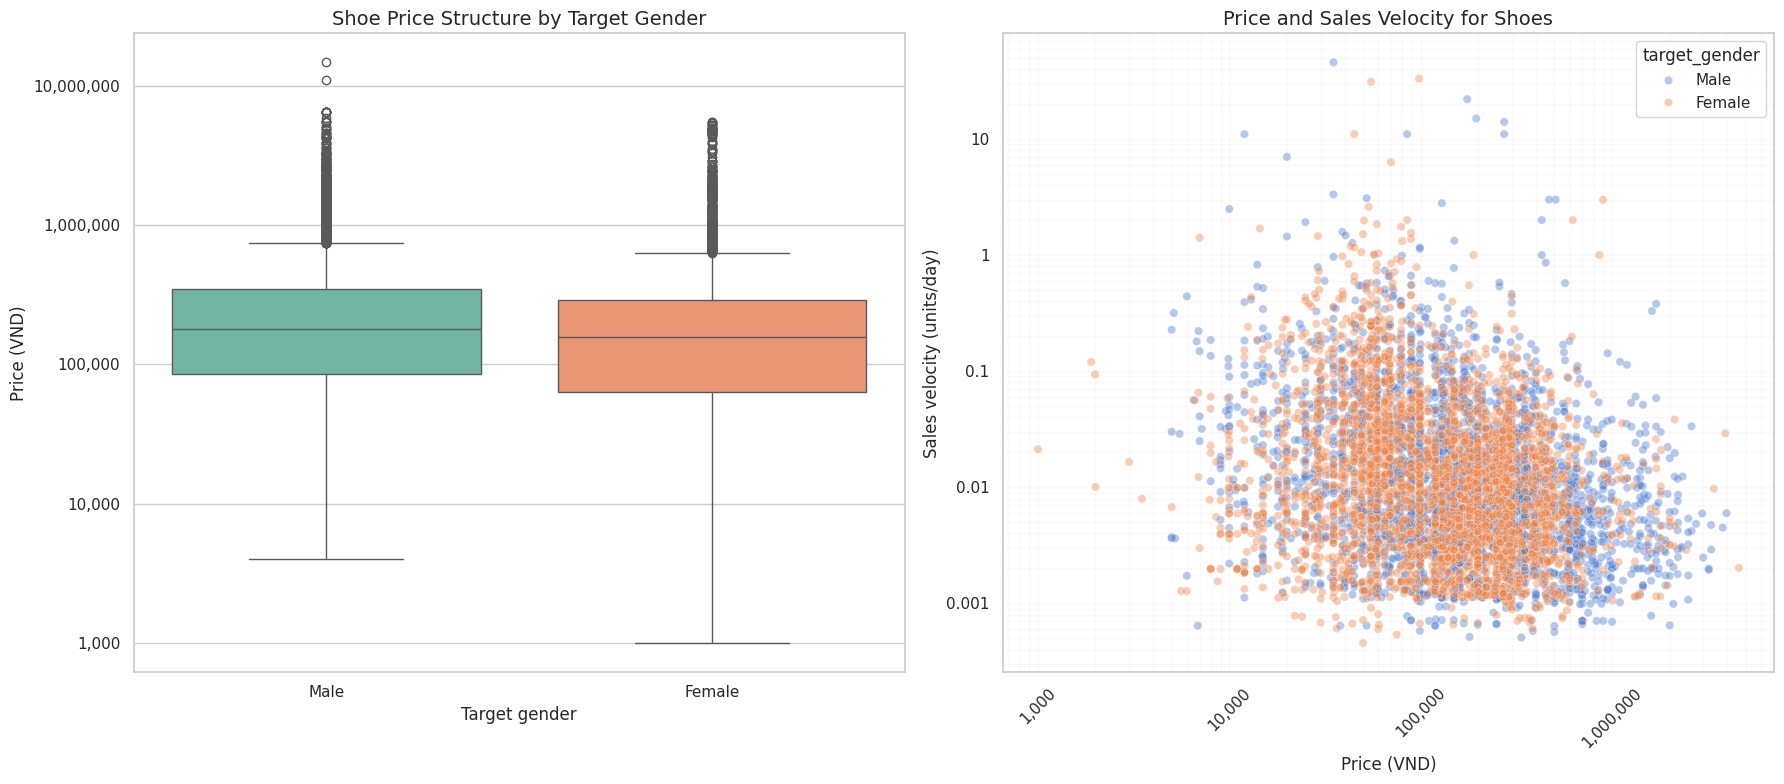

In [26]:
# Source alignment: shoes analysis from PhanTich notebook.
df_shoes = df_tiki[
    (df_tiki['main_category'] == 'Shoes') &
    (df_tiki['date_created'] <= 5000) &
    (df_tiki['price'] > 0) &
    (df_tiki['target_gender'].isin(['Male', 'Female']))
].copy()
df_shoes['sales_velocity'] = df_shoes['quantity_sold'] / (df_shoes['date_created'] + 1)

median_shoe_price = df_shoes.groupby('target_gender')['price'].median()
print('=== Shoes descriptive statistics ===')
for gender, value in median_shoe_price.items():
    print(f'Median shoe price - {gender}: {value:,.0f} VND')

def format_number(value, position):
    if value >= 1:
        return f'{int(value):,}'
    if value > 0:
        return f'{value:.3f}'.rstrip('0').rstrip('.')
    return '0'

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_shoes, x='target_gender', y='price', palette='Set2')
ax1 = plt.gca()
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(FuncFormatter(format_number))
plt.title('Shoe Price Structure by Target Gender', fontsize=14)
plt.ylabel('Price (VND)')
plt.xlabel('Target gender')

plt.subplot(1, 2, 2)
df_shoes_active = df_shoes[df_shoes['quantity_sold'] > 0].copy()
sns.scatterplot(data=df_shoes_active, x='price', y='sales_velocity', hue='target_gender', alpha=0.4)
ax2 = plt.gca()
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.xaxis.set_major_formatter(FuncFormatter(format_number))
ax2.yaxis.set_major_formatter(FuncFormatter(format_number))
plt.title('Price and Sales Velocity for Shoes', fontsize=14)
plt.xlabel('Price (VND)')
plt.ylabel('Sales velocity (units/day)')
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='-', alpha=0.1)
plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The shoe charts compare male and female target groups through price distribution and sales velocity. The boxplot focuses on price structure, while the scatter plot checks whether higher or lower price ranges are associated with stronger sales speed.


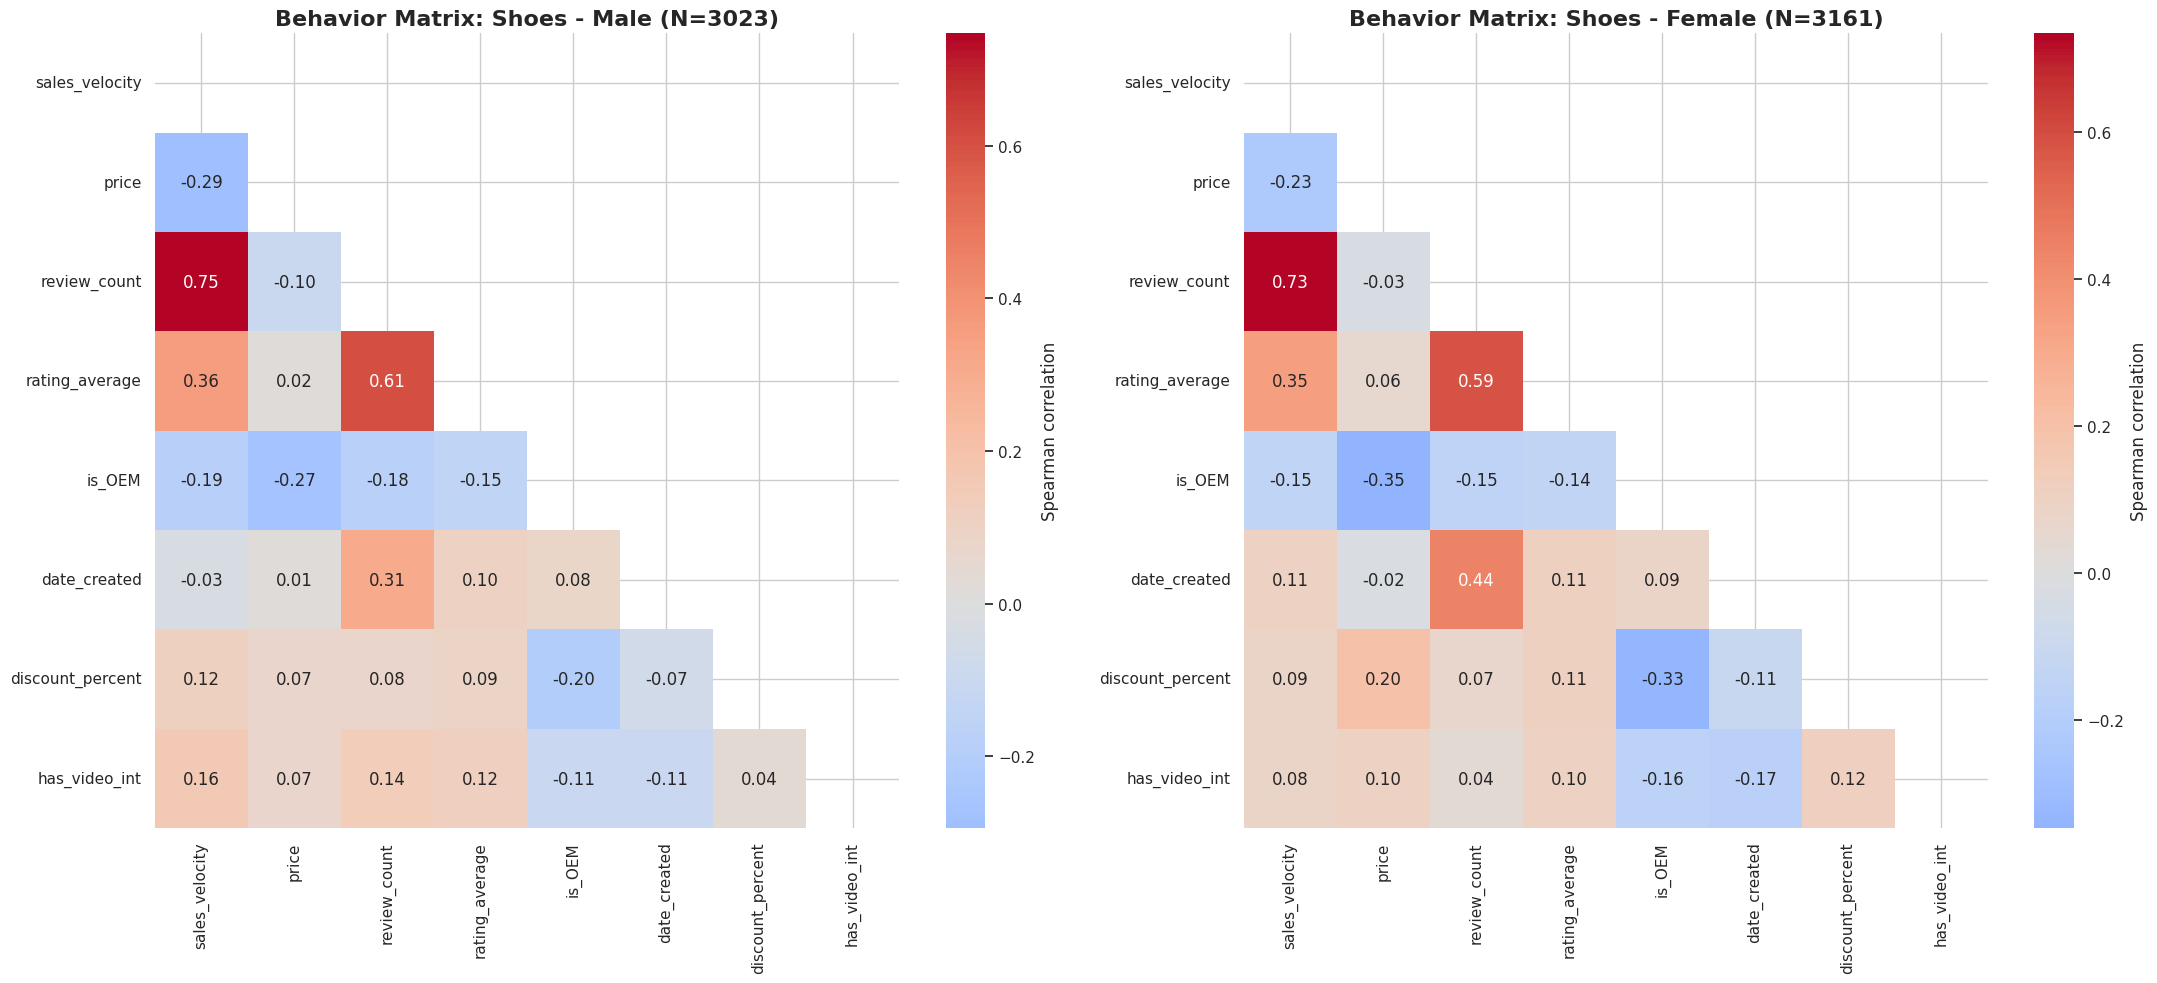

In [27]:
# Source alignment: shoes behavioral Spearman matrices.
df_shoes['is_OEM'] = (df_shoes['brand'] == 'OEM').astype(int)
df_shoes['has_video_int'] = df_shoes['has_video'].astype(int)
df_shoes['discount_percent'] = np.where(
    df_shoes['original_price'] > 0,
    ((df_shoes['original_price'] - df_shoes['price']) / df_shoes['original_price']) * 100,
    0
)
df_shoes_active = df_shoes[df_shoes['quantity_sold'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
cols = ['sales_velocity', 'price', 'review_count', 'rating_average', 'is_OEM', 'date_created', 'discount_percent', 'has_video_int']

for i, gender in enumerate(['Male', 'Female']):
    data_gen = df_shoes_active[df_shoes_active['target_gender'] == gender]
    corr = data_gen[cols].corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, ax=axes[i], fmt='.2f', cbar_kws={'label': 'Spearman correlation'})
    axes[i].set_title(f'Behavior Matrix: Shoes - {gender} (N={len(data_gen)})', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The two Spearman heatmaps show behavioral relationships separately for male and female shoes. Spearman correlation is appropriate here because the variables are skewed and include outliers, especially price, reviews, and sales velocity.


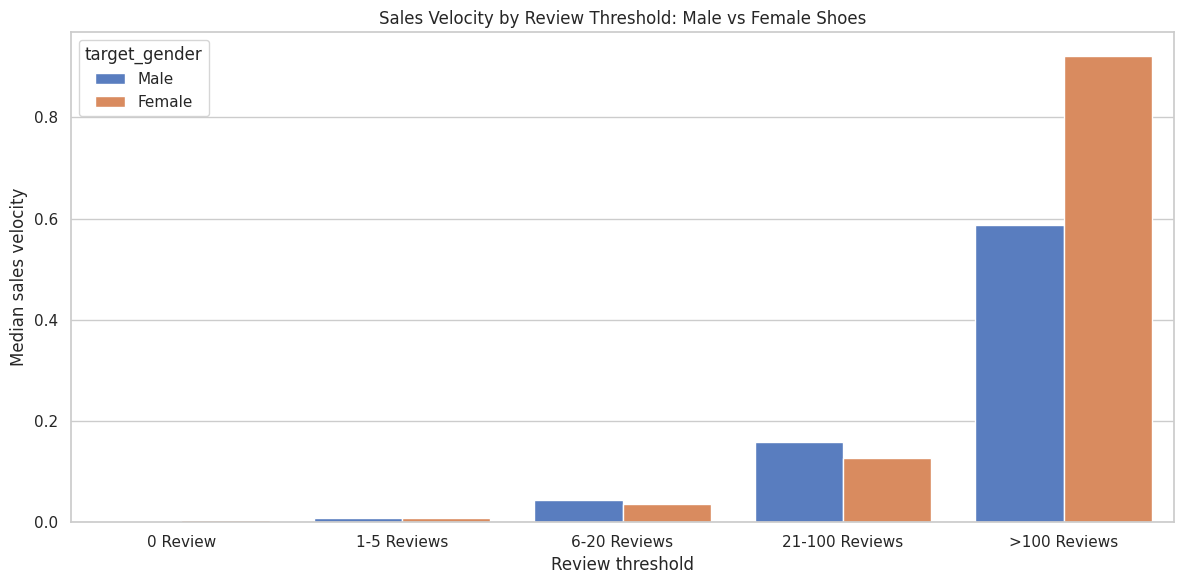

In [28]:
# Source alignment: review threshold effect for shoes.
review_bins_shoes = [-1, 0, 5, 20, 100, 10000]
review_labels_shoes = ['0 Review', '1-5 Reviews', '6-20 Reviews', '21-100 Reviews', '>100 Reviews']
df_shoes_active['review_group'] = pd.cut(df_shoes_active['review_count'], bins=review_bins_shoes, labels=review_labels_shoes)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_shoes_active, x='review_group', y='sales_velocity', hue='target_gender', estimator=np.median, errorbar=None)
plt.title('Sales Velocity by Review Threshold: Male vs Female Shoes')
plt.ylabel('Median sales velocity')
plt.xlabel('Review threshold')
plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The review-threshold barplot checks whether sales velocity increases after products accumulate more reviews. This chart connects the gender analysis with the broader social-proof insight from the rating-paradox section.


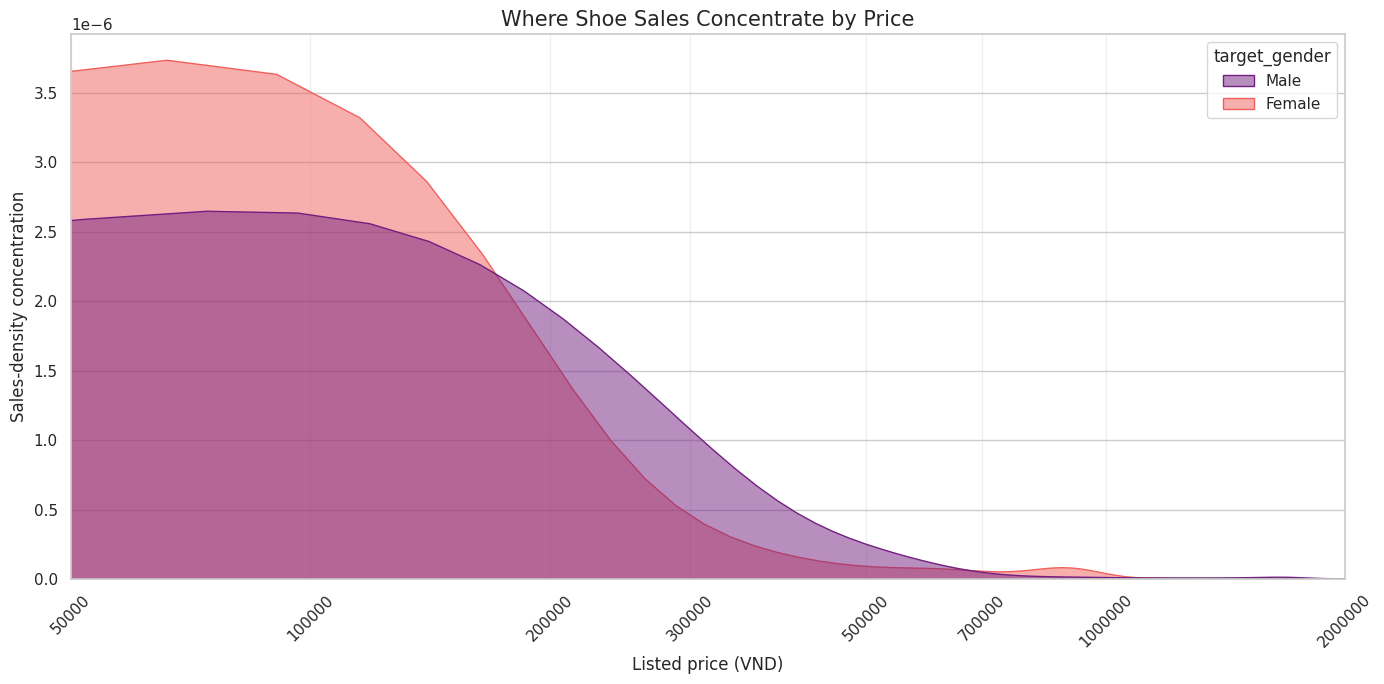

=== Dead-price threshold approximation for shoes ===
Male shoes: 90% of active products are below 680,000 VND
Female shoes: 90% of active products are below 430,000 VND


In [29]:
# Source alignment: where shoe sales concentrate by price.
df_active_shoes = df_shoes[df_shoes['quantity_sold'] > 0].copy()

plt.figure(figsize=(14, 7))
sns.kdeplot(
    data=df_active_shoes,
    x='price',
    hue='target_gender',
    weights='sales_velocity',
    fill=True,
    common_norm=False,
    palette='magma',
    alpha=0.5
)
ax = plt.gca()
ax.set_xscale('log')
xfmt = ScalarFormatter()
xfmt.set_scientific(False)
xfmt.set_useOffset(False)
ax.xaxis.set_major_formatter(xfmt)
plt.xlim(50000, 2000000)
plt.title('Where Shoe Sales Concentrate by Price', fontsize=15)
plt.xlabel('Listed price (VND)')
plt.ylabel('Sales-density concentration')
plt.grid(axis='x', alpha=0.3)
plt.xticks([50000, 100000, 200000, 300000, 500000, 700000, 1000000, 2000000], rotation=45)
plt.tight_layout()
plt.show()

print('=== Dead-price threshold approximation for shoes ===')
for gender in ['Male', 'Female']:
    sub = df_active_shoes[df_active_shoes['target_gender'] == gender]
    if len(sub):
        price_90 = sub.sort_values('price').iloc[int(len(sub) * 0.9)]['price']
        print(f'{gender} shoes: 90% of active products are below {price_90:,.0f} VND')


<!-- chart-explanation-v2 -->
**Chart interpretation.** The weighted KDE plot shows where active shoe sales concentrate along the price axis. Weighting by sales velocity shifts attention from SKU availability to the price ranges where actual demand is stronger.


In [30]:
# Source alignment: statistical tests for shoes.
def check_gender_significance_shoes(metric):
    male = df_shoes_active[df_shoes_active['target_gender'] == 'Male'][metric]
    female = df_shoes_active[df_shoes_active['target_gender'] == 'Female'][metric]
    stat, p = mannwhitneyu(male, female, alternative='two-sided')
    status = 'significant' if p < 0.05 else 'not significant'
    print(f'{metric}: p-value = {p:.4f} ({status})')

print('=== Reliability check for shoe conclusions ===')
check_gender_significance_shoes('price')
check_gender_significance_shoes('sales_velocity')


=== Reliability check for shoe conclusions ===
price: p-value = 0.0000 (significant)
sales_velocity: p-value = 0.0005 (significant)


=== Bags category audit ===
Total SKU: 8,550
Category composition (%):


,proportion
target_gender,
Female,50.56
Male,49.44


Median bag price:
- Female: 69,000 VND
- Male: 185,000 VND


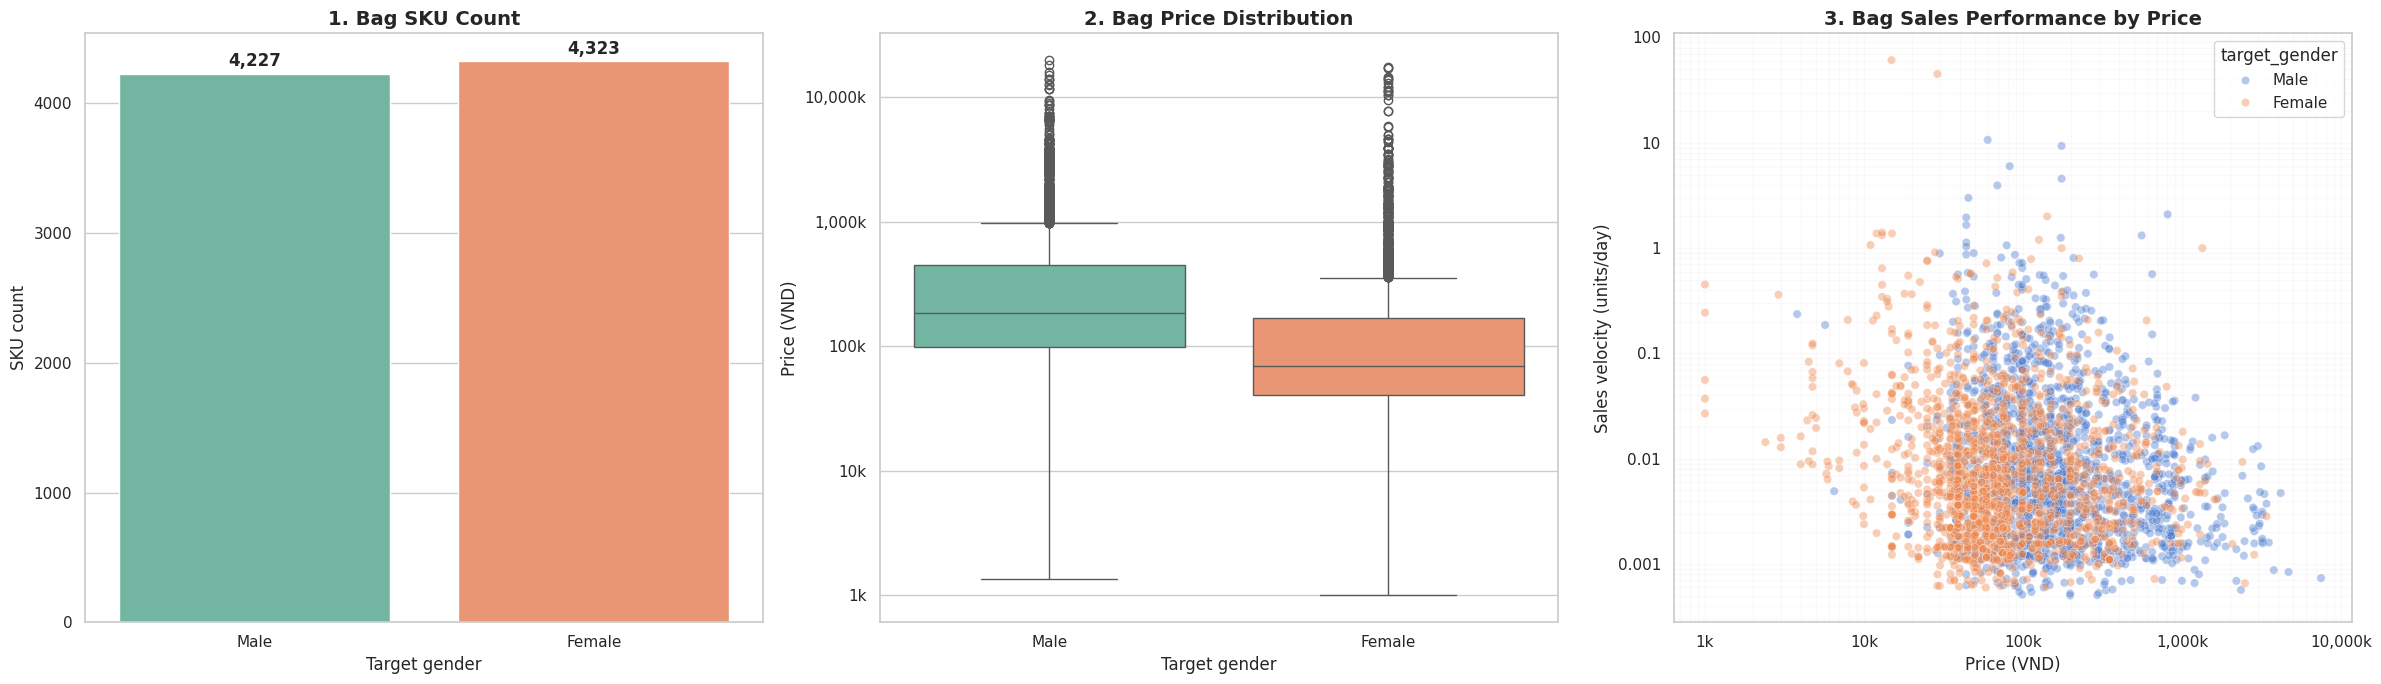

In [31]:
# Source alignment: bags analysis from PhanTich notebook.
df_bags_gender = df_tiki[
    (df_tiki['main_category'] == 'Bags') &
    (df_tiki['date_created'] <= 5000) &
    (df_tiki['price'] > 0) &
    (df_tiki['target_gender'].isin(['Male', 'Female']))
].copy()
df_bags_gender['sales_velocity'] = df_bags_gender['quantity_sold'] / (df_bags_gender['date_created'] + 1)

median_bag_price = df_bags_gender.groupby('target_gender')['price'].median()
print('=== Bags category audit ===')
print(f'Total SKU: {len(df_bags_gender):,}')
print('Category composition (%):')
display((df_bags_gender['target_gender'].value_counts(normalize=True) * 100).round(2))
print('Median bag price:')
for gender, value in median_bag_price.items():
    print(f'- {gender}: {value:,.0f} VND')

def compact_number(value, position):
    if value >= 1000:
        return f'{int(value / 1000):,}k'
    if value >= 1:
        return f'{int(value):,}'
    if value > 0:
        return f'{value:.3f}'.rstrip('0').rstrip('.')
    return '0'

plt.figure(figsize=(24, 7))
plt.subplot(1, 3, 1)
sns.countplot(data=df_bags_gender, x='target_gender', palette='Set2')
ax1 = plt.gca()
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.title('1. Bag SKU Count', fontsize=14, fontweight='bold')
plt.xlabel('Target gender')
plt.ylabel('SKU count')

plt.subplot(1, 3, 2)
sns.boxplot(data=df_bags_gender, x='target_gender', y='price', palette='Set2')
ax2 = plt.gca()
ax2.set_yscale('log')
ax2.yaxis.set_major_formatter(FuncFormatter(compact_number))
plt.title('2. Bag Price Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Price (VND)')
plt.xlabel('Target gender')

plt.subplot(1, 3, 3)
df_active_bags = df_bags_gender[df_bags_gender['quantity_sold'] > 0].copy()
sns.scatterplot(data=df_active_bags, x='price', y='sales_velocity', hue='target_gender', alpha=0.4)
ax3 = plt.gca()
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.xaxis.set_major_formatter(FuncFormatter(compact_number))
ax3.yaxis.set_major_formatter(FuncFormatter(compact_number))
plt.title('3. Bag Sales Performance by Price', fontsize=14, fontweight='bold')
plt.xlabel('Price (VND)')
plt.ylabel('Sales velocity (units/day)')
plt.grid(True, which='both', ls='-', alpha=0.1)
plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The bag analysis mirrors the shoe analysis with SKU count, price distribution, and sales performance. Including bags helps avoid drawing gender-related conclusions from shoes alone, because category structure can strongly affect price and sales behavior.


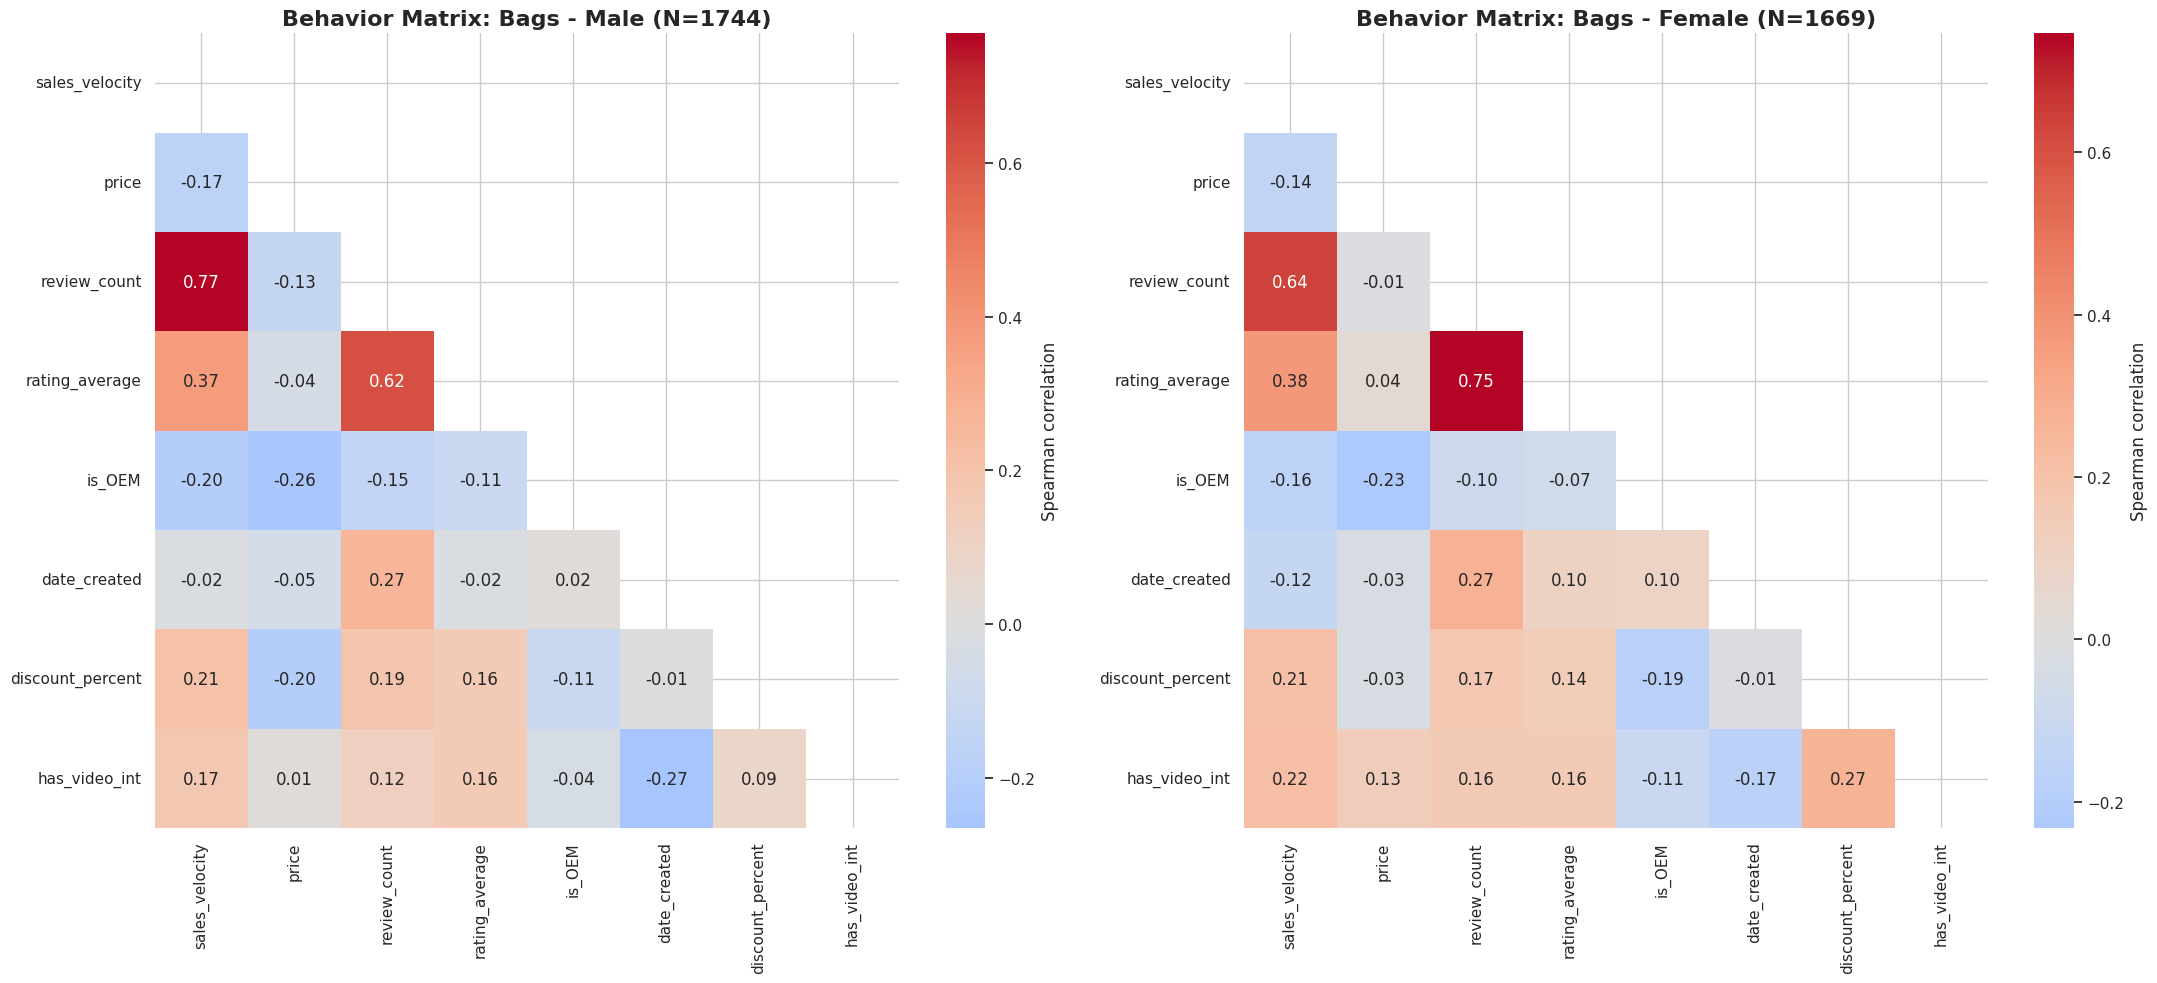

In [32]:
# Source alignment: bags behavioral Spearman matrices.
df_bags_gender['is_OEM'] = (df_bags_gender['brand'] == 'OEM').astype(int)
df_bags_gender['has_video_int'] = df_bags_gender['has_video'].astype(int)
df_bags_gender['discount_percent'] = np.where(
    df_bags_gender['original_price'] > 0,
    ((df_bags_gender['original_price'] - df_bags_gender['price']) / df_bags_gender['original_price']) * 100,
    0
)

df_bags_active = df_bags_gender[df_bags_gender['quantity_sold'] > 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
cols = ['sales_velocity', 'price', 'review_count', 'rating_average', 'is_OEM', 'date_created', 'discount_percent', 'has_video_int']

for i, gender in enumerate(['Male', 'Female']):
    data_gen = df_bags_active[df_bags_active['target_gender'] == gender]
    corr = data_gen[cols].corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, ax=axes[i], fmt='.2f', cbar_kws={'label': 'Spearman correlation'})
    axes[i].set_title(f'Behavior Matrix: Bags - {gender} (N={len(data_gen)})', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The bag heatmaps compare behavioral correlations for male and female target groups. These charts help identify whether relationships involving price, reviews, discount, OEM status, and video repeat across gender-category groups.


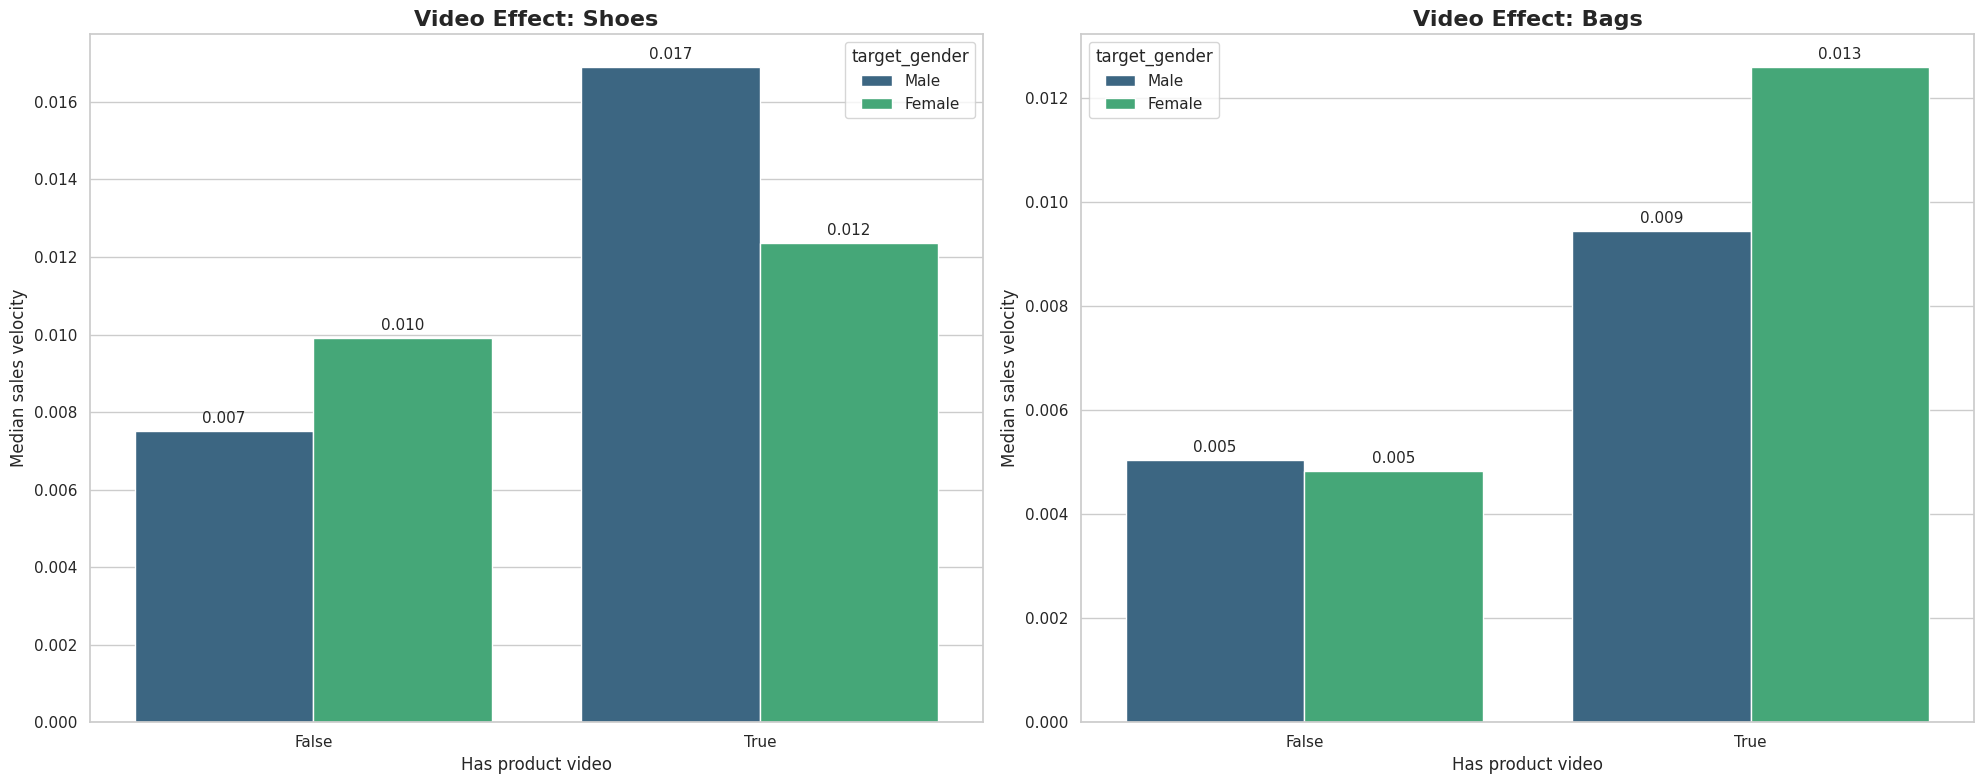

=== Statistical test for product-video effect ===
Shoes: p-value = 0.0000000000
Bags: p-value = 0.0000000000


In [33]:
# Source alignment: video effect across shoes and bags.
df_gender = df_tiki[
    (df_tiki['main_category'].isin(['Shoes', 'Bags'])) &
    (df_tiki['target_gender'].isin(['Male', 'Female'])) &
    (df_tiki['date_created'] <= 5000) &
    (df_tiki['quantity_sold'] > 0) &
    (df_tiki['price'] > 0)
].copy()
df_gender['sales_velocity'] = df_gender['quantity_sold'] / (df_gender['date_created'] + 1)
df_gender['gender_category'] = df_gender['main_category'] + ' - ' + df_gender['target_gender']
df_gender['has_discount'] = (df_gender['discount_percent'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, category in enumerate(['Shoes', 'Bags']):
    df_sub = df_gender[df_gender['main_category'] == category]
    sns.barplot(data=df_sub, x='has_video', y='sales_velocity', hue='target_gender', estimator=np.median, ax=axes[i], palette='viridis', errorbar=None)
    for p in axes[i].patches:
        if p.get_height() > 0:
            axes[i].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)
    axes[i].set_title(f'Video Effect: {category}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Median sales velocity')
    axes[i].set_xlabel('Has product video')

plt.tight_layout()
plt.show()

print('=== Statistical test for product-video effect ===')
for category in ['Shoes', 'Bags']:
    df_cat = df_gender[df_gender['main_category'] == category]
    group_video = df_cat[df_cat['has_video'] == True]['sales_velocity']
    group_no_video = df_cat[df_cat['has_video'] == False]['sales_velocity']
    if len(group_video) and len(group_no_video):
        stat, p = mannwhitneyu(group_video, group_no_video, alternative='two-sided')
        print(f'{category}: p-value = {p:.10f}')
    else:
        print(f'{category}: not enough observations for the test')


<!-- chart-explanation-v2 -->
**Chart interpretation.** The video-effect charts compare sales velocity between products with and without product videos in both shoes and bags. The accompanying Mann-Whitney tests indicate whether the observed visual differences are statistically meaningful.


In [34]:
# Unified gender summary kept for downstream hypothesis testing in Part 5.
gender_summary = (
    df_gender
    .groupby(['main_category', 'target_gender'])
    .agg(
        SKU_count=('id', 'count'),
        median_price=('price', 'median'),
        discount_coverage=('has_discount', 'mean'),
        median_reviews=('review_count', 'median'),
        mean_rating=('rating_average', 'mean'),
        median_sales_velocity=('sales_velocity', 'median'),
        tiki_delivery_rate=('is_tiki_delivery', 'mean'),
        BNPL_rate=('pay_later', 'mean')
    )
)

gender_summary[['discount_coverage', 'tiki_delivery_rate', 'BNPL_rate']] = (
    gender_summary[['discount_coverage', 'tiki_delivery_rate', 'BNPL_rate']] * 100
).round(2)
gender_summary['mean_rating'] = gender_summary['mean_rating'].round(2)
display(gender_summary)


SKU_count  median_price  discount_coverage  \
main_category target_gender                                               
Bags          Female              1669       65000.0              24.69   
              Male                1744      141900.0              44.95   
Shoes         Female              3161      129000.0              23.25   
              Male                3023      160000.0              26.99   

                             median_reviews  mean_rating  \
main_category target_gender                                
Bags          Female                    1.0         2.61   
              Male                      1.0         3.02   
Shoes         Female                    1.0         3.05   
              Male                      1.0         3.06   

                             median_sales_velocity  tiki_delivery_rate  \
main_category target_gender                                              
Bags          Female                      0.005576                1.74   
              Male                        0.006064                5.85   
Shoes         Female                      0.010165                2.82   
              Male                        0.008210                1.39   

                             BNPL_rate  
main_category target_gender             
Bags          Female             32.06  
              Male               65.31  
Shoes         Female             55.17  
              Male               64.27

### 3.5 Overall EDA Observations

The synchronized EDA preserves the outputs used in the presentation while keeping the final notebook consistent with the required pipeline. The key observations are:

- BNPL is strongly related to higher product prices and brand-level revenue structure, but it should not be interpreted as an automatic sales-volume booster.
- The rating paradox is mainly a social-proof problem: a perfect 5.0 score with very few reviews can be less persuasive than a 4.7-4.9 score supported by many reviews.
- Gender-category analysis should include both shoes and bags. This reduces the risk of mistaking category-specific behavior for a general gender effect.
- Review volume, price level, delivery convenience, video availability, and brand structure jointly shape observed sales behavior.


## Part 4: Probability Distribution Analysis


### 4.1 Selected Variable: `price`

`price` is directly related to BNPL, price sensitivity, and the sales prediction model. E-commerce data are typically right-skewed, so the analysis compares raw price with `log(price)`.


In [35]:
price_series = df_tiki['price'].dropna()
log_price = np.log(price_series)
print(price_series.describe())
print(f"Skewness: {price_series.skew():.3f}")
print(f"Kurtosis: {price_series.kurtosis():.3f}")


count    4.157500e+04
mean     2.723654e+05
std      7.630106e+05
min      1.000000e+03
25%      3.900000e+04
50%      8.500000e+04
75%      2.100000e+05
max      1.980000e+07
Name: price, dtype: float64
Skewness: 10.724
Kurtosis: 171.908


### 4.2 Histogram, KDE, and Theoretical Fit


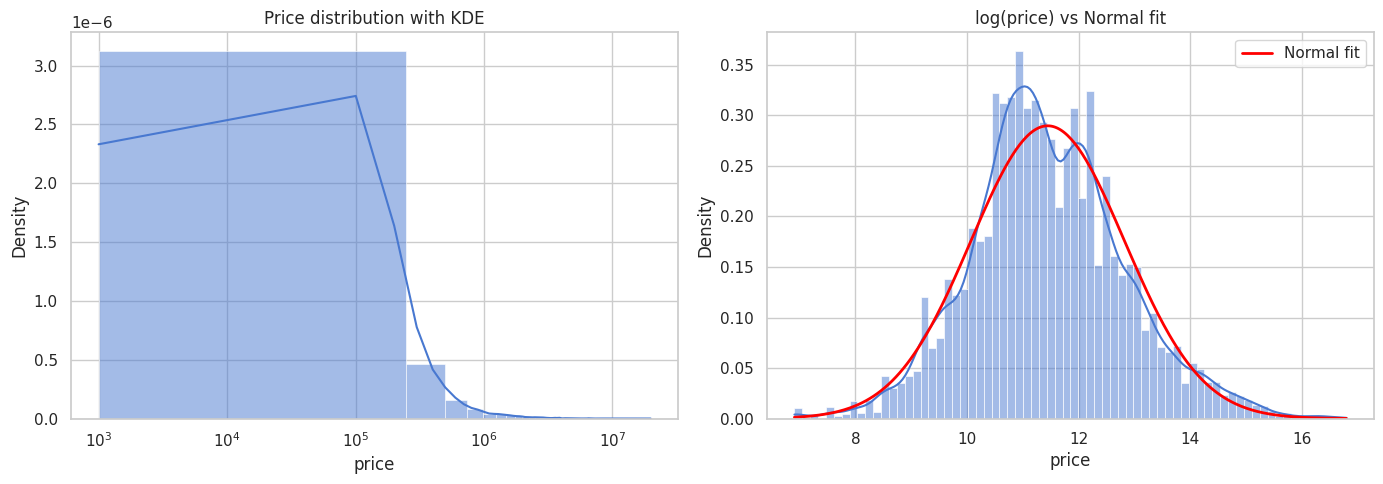

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(price_series, bins=80, stat='density', kde=True, ax=axes[0])
axes[0].set_xscale('log'); axes[0].set_title('Price distribution with KDE')
mu_log, std_log = log_price.mean(), log_price.std()
sns.histplot(log_price, bins=70, stat='density', kde=True, ax=axes[1])
x = np.linspace(log_price.min(), log_price.max(), 300)
axes[1].plot(x, norm.pdf(x, mu_log, std_log), color='red', lw=2, label='Normal fit')
axes[1].set_title('log(price) vs Normal fit'); axes[1].legend()
plt.tight_layout(); plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The histogram and KDE show that raw price is heavily right-skewed. The log-price panel with a normal fit is used because e-commerce prices are multiplicative in nature and become more interpretable after logarithmic transformation.


### 4.3 Q-Q Plot and KS Test

- H0: `log(price)` follows a Normal distribution, which means `price` approximately follows a Log-normal distribution.
- H1: `log(price)` does not follow a Normal distribution.
- Significance level: `alpha = 0.05`.


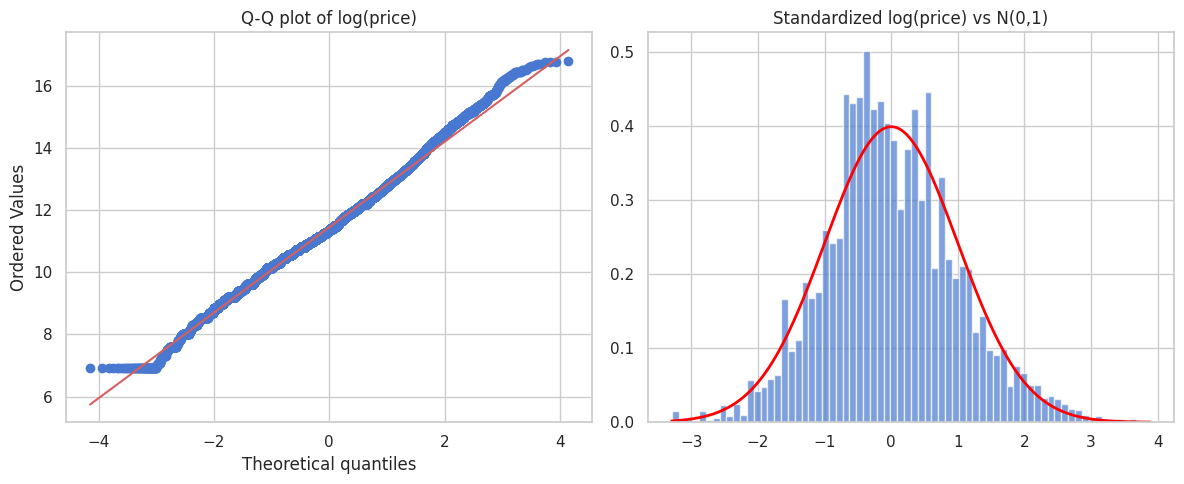

KS Statistic: 0.038203292568993796
P-value: 3.703252884013262e-53
Conclusion: Reject H0 - price is not perfectly Log-normal


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(log_price, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q plot of log(price)')
log_price_std = (log_price - mu_log) / std_log
axes[1].hist(log_price_std, bins=70, density=True, alpha=0.7)
x_std = np.linspace(log_price_std.min(), log_price_std.max(), 300)
axes[1].plot(x_std, norm.pdf(x_std), color='red', lw=2)
axes[1].set_title('Standardized log(price) vs N(0,1)')
plt.tight_layout(); plt.show()
ks_stat, ks_pval = kstest(log_price_std, 'norm')
print('KS Statistic:', ks_stat)
print('P-value:', ks_pval)
print('Conclusion:', 'Reject H0 - price is not perfectly Log-normal' if ks_pval < 0.05 else 'Fail to reject H0')


<!-- chart-explanation-v2 -->
**Chart interpretation.** The Q-Q plot and standardized log-price histogram evaluate whether log-price approximates a normal distribution. A statistical rejection does not invalidate the analysis; it mainly shows that real marketplace prices still deviate from an ideal theoretical distribution.


**Interpretation:** With a very large sample, the KS test can reject H0 even for small deviations. Therefore, Log-normal should be treated as an approximation. The main practical takeaway is that log transformation reduces right-skewness and is appropriate for later regression analysis.


## Part 5: Hypothesis Testing by Research Theme


### 5.1 Hypothesis 1 - Does Pay Later Increase `quantity_sold`?

- H0: The `quantity_sold` distributions of BNPL and Non-BNPL products are not different.
- H1: The two distributions are different.
- Test: Mann-Whitney U.


In [38]:
bnpl_yes = df_tiki[df_tiki['pay_later'] == True]['quantity_sold']
bnpl_no = df_tiki[df_tiki['pay_later'] == False]['quantity_sold']
stat, pval = mannwhitneyu(bnpl_yes, bnpl_no, alternative='two-sided')
print('Mann-Whitney U:', stat)
print('P-value:', pval)
print(f"Mean BNPL: {bnpl_yes.mean():.2f} | Mean Non-BNPL: {bnpl_no.mean():.2f}")
print(f"Median BNPL: {bnpl_yes.median():.2f} | Median Non-BNPL: {bnpl_no.median():.2f}")
if bnpl_no.mean() > 0:
    print(f"Mean uplift ratio: {bnpl_yes.mean() / bnpl_no.mean():.2f}x")
print('Conclusion:', 'Statistically significant difference' if pval < 0.05 else 'No statistically significant difference')


Mann-Whitney U: 201310778.5
P-value: 6.421204108358957e-27
Mean BNPL: 11.01 | Mean Non-BNPL: 23.19
Median BNPL: 0.00 | Median Non-BNPL: 0.00
Mean uplift ratio: 0.47x
Conclusion: Statistically significant difference


### 5.2 Hypothesis 2 - Does 4.7-4.9 Rating Outperform 5.0 Rating After Controlling for Reviews?

- H0: `quantity_sold` is not different between 5.0-star and 4.7-4.9-star products when `review_count >= 11`.
- H1: The two groups are different.
- Test: Mann-Whitney U.


In [39]:
rating_test = df_tiki[(df_tiki['review_count'] >= 11) & (df_tiki['rating_tier'].isin(['5.0 star','4.7-4.9 star']))].copy()
grp_50 = rating_test[rating_test['rating_tier'] == '5.0 star']['quantity_sold']
grp_48 = rating_test[rating_test['rating_tier'] == '4.7-4.9 star']['quantity_sold']
stat, pval = mannwhitneyu(grp_50, grp_48, alternative='two-sided')
print('Mann-Whitney U:', stat)
print('P-value:', pval)
print(f"Median 5.0 star: {grp_50.median():.2f}")
print(f"Median 4.7-4.9 star: {grp_48.median():.2f}")
print('Conclusion:', 'Statistically significant difference' if pval < 0.05 else 'No statistically significant difference')


Mann-Whitney U: 94767.0
P-value: 1.9912576041524798e-05
Median 5.0 star: 73.00
Median 4.7-4.9 star: 102.00
Conclusion: Statistically significant difference


### 5.3 Hypothesis 3 - Do Gender Differences Repeat Across Shoes and Bags?

- H0: Within each category (`Shoes`, `Bags`), the distribution of each metric is not different between male-targeted and female-targeted products.
- H1: Within each category, the distribution of each metric is different between the two gender groups.
- Test: Mann-Whitney U for `price`, `discount_percent`, `review_count`, `sales_velocity`, and `is_tiki_delivery`.
- Interpretation rule: A gender pattern should only be described as cross-category if it is consistent across both shoes and bags. Otherwise, it should be interpreted as category-specific.


In [40]:
metrics = ['price', 'discount_percent', 'review_count', 'sales_velocity', 'is_tiki_delivery']
results = []

for category in ['Shoes', 'Bags']:
    df_cat = df_gender[df_gender['main_category'] == category]

    for metric in metrics:
        male = df_cat[df_cat['target_gender'] == 'Male'][metric]
        female = df_cat[df_cat['target_gender'] == 'Female'][metric]

        if len(male) == 0 or len(female) == 0:
            continue

        stat, pval = mannwhitneyu(male, female, alternative='two-sided')
        results.append({
            'category': category,
            'metric': metric,
            'median_male': male.median(),
            'median_female': female.median(),
            'male_minus_female': male.median() - female.median(),
            'p_value': pval,
            'significant_5pct': pval < 0.05
        })

gender_test_result = pd.DataFrame(results)
display(gender_test_result)

consistency = (
    gender_test_result
    .pivot_table(
        index='metric',
        columns='category',
        values='male_minus_female',
        aggfunc='first'
    )
)

display(consistency)


,category,metric,median_male,median_female,male_minus_female,p_value,significant_5pct
0,Shoes,price,160000.000000,129000.000000,31000.000000,1.262169e-18,True
1,Shoes,discount_percent,0.000000,0.000000,0.000000,2.846421e-04,True
2,Shoes,review_count,1.000000,1.000000,0.000000,1.872403e-02,True
3,Shoes,sales_velocity,0.008210,0.010165,-0.001955,5.347037e-04,True
4,Shoes,is_tiki_delivery,0.000000,0.000000,0.000000,9.898366e-05,True
5,Bags,price,141900.000000,65000.000000,76900.000000,2.778141e-108,True
6,Bags,discount_percent,0.000000,0.000000,0.000000,9.306481e-28,True
7,Bags,review_count,1.000000,1.000000,0.000000,6.361119e-14,True
8,Bags,sales_velocity,0.006064,0.005576,0.000487,3.477915e-01,False
9,Bags,is_tiki_delivery,0.000000,0.000000,0.000000,4.153677e-10,True


category,Bags,Shoes
metric,,
discount_percent,0.000000,0.000000
is_tiki_delivery,0.000000,0.000000
price,76900.000000,31000.000000
review_count,0.000000,0.000000
sales_velocity,0.000487,-0.001955


## Part 6: Correlation Analysis


### 6.1 Spearman Correlation Heatmap for Men's and Women's Bags

Spearman correlation is used because the key variables are right-skewed, contain outliers, and may have monotonic but non-linear relationships.


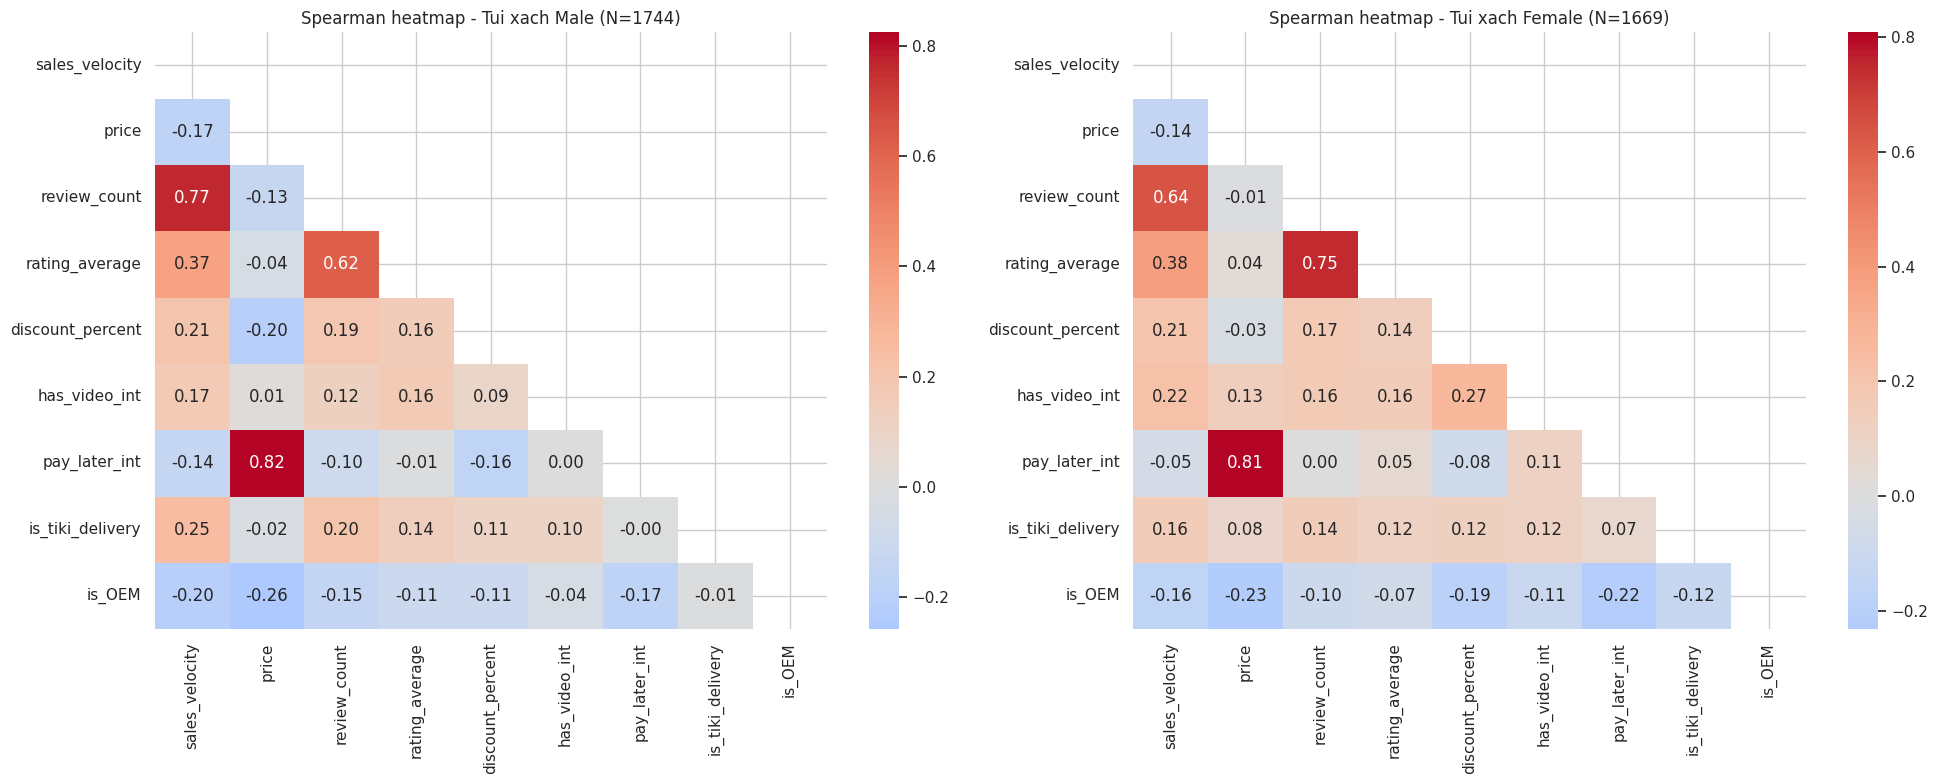

In [41]:
df_bags = df_tiki[(df_tiki['main_category'] == 'Bags') & (df_tiki['quantity_sold'] > 0)].copy()
bag_corr_cols = ['sales_velocity','price','review_count','rating_average','discount_percent','has_video_int','pay_later_int','is_tiki_delivery','is_OEM']
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, gender in enumerate(['Male','Female']):
    data_gen = df_bags[df_bags['target_gender'] == gender]
    corr = data_gen[bag_corr_cols].corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[i])
    axes[i].set_title(f'Spearman heatmap - Tui xach {gender} (N={len(data_gen)})')
plt.tight_layout(); plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The Spearman heatmaps for men's and women's bags summarize monotonic relationships among sales velocity, price, review signals, discount, video, BNPL, delivery, and OEM status. This supports the gender-category discussion using a compact correlation view.


### 6.2 Scatter Plots for Important Variable Pairs


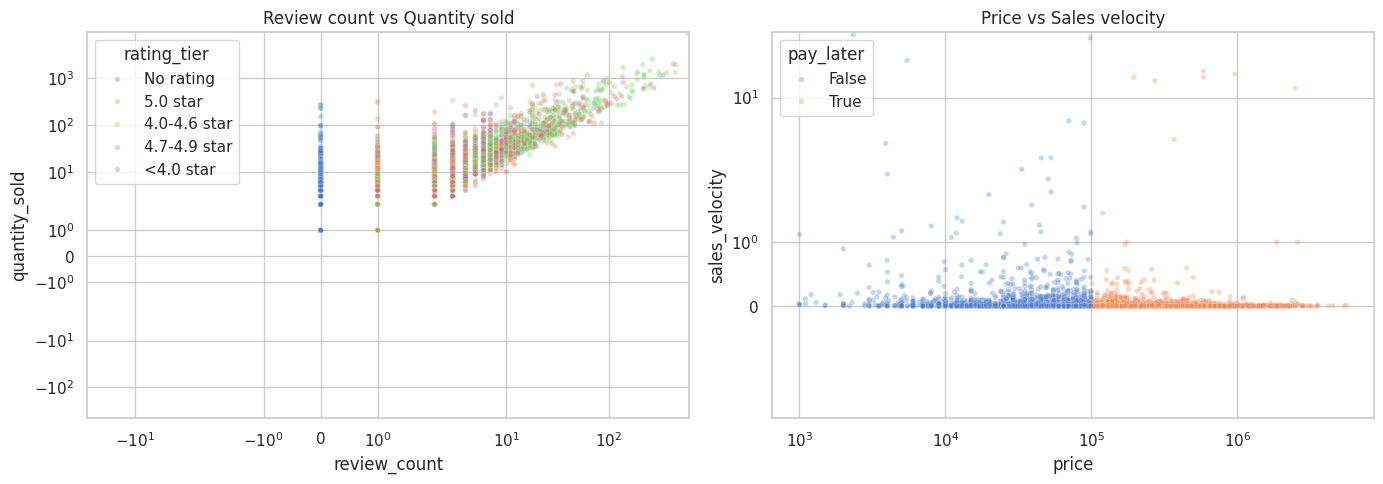

In [42]:
df_corr = df_tiki[df_tiki['quantity_sold'] > 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_sample = df_corr.sample(min(5000, len(df_corr)), random_state=42)
sns.scatterplot(data=plot_sample, x='review_count', y='quantity_sold', hue='rating_tier', alpha=0.3, s=15, ax=axes[0])
axes[0].set_xscale('symlog'); axes[0].set_yscale('symlog'); axes[0].set_title('Review count vs Quantity sold')
sns.scatterplot(data=plot_sample, x='price', y='sales_velocity', hue='pay_later', alpha=0.3, s=15, ax=axes[1])
axes[1].set_xscale('log'); axes[1].set_yscale('symlog'); axes[1].set_title('Price vs Sales velocity')
plt.tight_layout(); plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The scatter plots illustrate two important relationships: review volume versus sales quantity, and price versus sales velocity. Symlog/log scales are used to keep dense low-value observations visible while still showing high-performing outliers.


### 6.3 Top Correlated Variable Pairs


In [43]:
corr_cols = ['sales_velocity','quantity_sold','price','review_count','rating_average','discount_percent','has_video_int','pay_later_int','is_tiki_delivery','is_OEM']
corr_mat = df_corr[corr_cols].corr(method='spearman')
pairs = []
for i, a in enumerate(corr_cols):
    for b in corr_cols[i+1:]:
        pairs.append({'var_1':a, 'var_2':b, 'spearman_r':corr_mat.loc[a,b], 'abs_r':abs(corr_mat.loc[a,b])})
top_corr_pairs = pd.DataFrame(pairs).sort_values('abs_r', ascending=False).head(10).drop(columns='abs_r')
display(top_corr_pairs)


,var_1,var_2,spearman_r
0,sales_velocity,quantity_sold,0.919018
21,price,pay_later_int,0.857790
10,quantity_sold,review_count,0.774455
2,sales_velocity,review_count,0.701734
24,review_count,rating_average,0.682094
11,quantity_sold,rating_average,0.411335
3,sales_velocity,rating_average,0.383753
23,price,is_OEM,-0.306816
38,discount_percent,is_OEM,-0.258044
43,pay_later_int,is_OEM,-0.246774


**Practical interpretation:** `review_count` represents social proof, `price` represents purchase friction, and `pay_later_int` plus `is_tiki_delivery` represent tools that reduce perceived purchase risk.


## Part 7: Multiple Linear Regression (MLR)


### Regression Model

$$\hat{y} = \beta_0 + \beta_1 x_1 + ... + \beta_k x_k + \varepsilon$$

The target variable is `log_qty_sold = log1p(quantity_sold)`. Independent variables include price, review count, rating, discount, video, BNPL, delivery, category, gender, and price segment.


### 7.1 Prepare Data and Encode Categorical Variables


In [44]:
df_mlr = df_tiki[(df_tiki['price'] > 0) & (df_tiki['date_created'] >= 0)].copy()
df_mlr['log_qty_sold'] = np.log1p(df_mlr['quantity_sold'])
df_mlr['log_price'] = np.log(df_mlr['price'])
df_mlr['log_review_count'] = np.log1p(df_mlr['review_count'])
df_mlr['log_date_created'] = np.log1p(df_mlr['date_created'])
base_features = ['log_price','log_review_count','rating_average','discount_percent','has_video_int','pay_later_int','is_tiki_delivery','is_OEM','log_date_created']
category_dummies = pd.get_dummies(df_mlr[['main_category','target_gender','price_segment']], drop_first=True, dtype=int)
X_all = pd.concat([df_mlr[base_features], category_dummies], axis=1)
y_all = df_mlr['log_qty_sold']
df_mlr_clean = pd.concat([X_all, y_all], axis=1).dropna()
FEATURES = [c for c in df_mlr_clean.columns if c != 'log_qty_sold']
TARGET = 'log_qty_sold'
print(df_mlr_clean.shape)
print(FEATURES)


(41575, 19)
['log_price', 'log_review_count', 'rating_average', 'discount_percent', 'has_video_int', 'pay_later_int', 'is_tiki_delivery', 'is_OEM', 'log_date_created', 'main_category_Backpacks - Suitcases', 'main_category_Bags', 'main_category_Shoes', 'target_gender_Male', 'target_gender_Unisex', 'price_segment_100k-300k', 'price_segment_300k-500k', 'price_segment_500k-1m', 'price_segment_>1m']


### 7.2 Check Multicollinearity with VIF


In [45]:
X_vif = sm.add_constant(df_mlr_clean[FEATURES])
vif_data = pd.DataFrame({'Bien': FEATURES, 'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(FEATURES))]})
display(vif_data.sort_values('VIF', ascending=False))


,Bien,VIF
13,target_gender_Unisex,inf
11,main_category_Shoes,inf
10,main_category_Bags,inf
5,pay_later_int,53.371567
14,price_segment_100k-300k,43.564797
15,price_segment_300k-500k,16.064849
16,price_segment_500k-1m,13.451572
17,price_segment_>1m,12.681312
0,log_price,4.925211
1,log_review_count,2.835123


### 7.3 Fit the OLS Model


In [46]:
X = df_mlr_clean[FEATURES]
y = df_mlr_clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:           log_qty_sold   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     8239.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        04:57:49   Log-Likelihood:                -32303.
No. Observations:               33260   AIC:                         6.464e+04
Df Residuals:                   33242   BIC:                         6.479e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

### 7.4 Evaluate the Model


In [47]:
X_test_sm = sm.add_constant(X_test)
y_pred = ols_model.predict(X_test_sm)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"Adjusted R2 train: {ols_model.rsquared_adj:.4f}")


R2   : 0.8045
MSE  : 0.4029
RMSE : 0.6348
Adjusted R2 train: 0.8081


### 7.5 Residual diagnostics


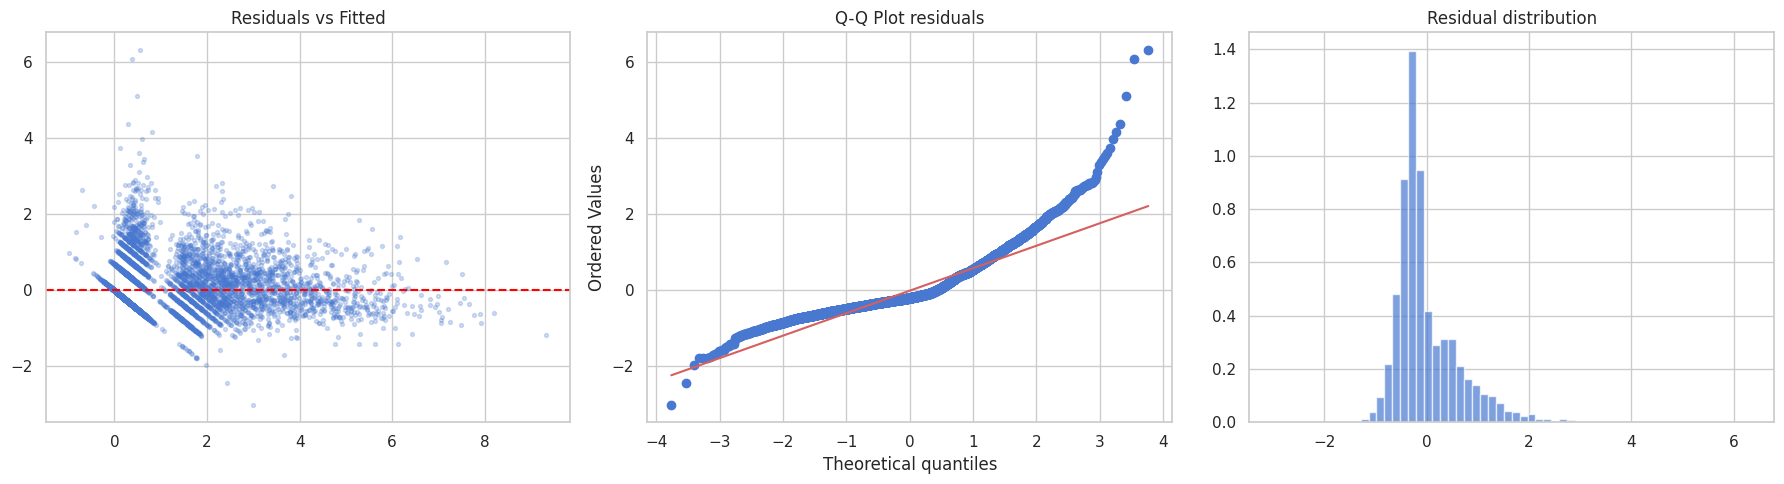

In [48]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_pred, residuals, alpha=0.25, s=8)
axes[0].axhline(0, color='red', ls='--'); axes[0].set_title('Residuals vs Fitted')
stats.probplot(residuals, dist='norm', plot=axes[1]); axes[1].set_title('Q-Q Plot residuals')
axes[2].hist(residuals, bins=60, density=True, alpha=0.7); axes[2].set_title('Residual distribution')
plt.tight_layout(); plt.show()


<!-- chart-explanation-v2 -->
**Chart interpretation.** The residual diagnostics evaluate whether the multiple linear regression model leaves systematic patterns unexplained. Residual-vs-fitted, Q-Q, and histogram views help assess linearity, normality of errors, and remaining skewness after transformation.


### Regression Interpretation

The model shows that `log_review_count` is the strongest predictor of `log_qty_sold`, confirming the importance of social proof. `log_price` has a negative coefficient, indicating that higher prices are associated with lower sales volume. `is_tiki_delivery` and `has_video_int` have positive effects, suggesting that delivery trust and richer product presentation support sales performance. The coefficient of `pay_later_int` is not statistically significant after controlling for other variables, so BNPL should be interpreted mainly as a high-value product support mechanism rather than a direct sales-volume driver.
